# exp09 diagnostics - did closing the loss-hacking channel close the model-selection void?

**Origin.** Yue Ma (2026-08-13) made a *causal* claim about the void, which exp09 exists to test:

```
  objective contains an exploitable channel
      -->  the loss can be driven down WITHOUT learning
      -->  therefore the loss cannot rank representations
      -->  close the channel  ==>  the loss may become usable again
```

**What exp09 is not.** It is not "fix the artifact". exp07 already measured the artifact as
probe-harmless (`numax_hon` +0.0001 +/- 0.0037). exp09 asks only whether closing it restores
*selectability*.

**The pipeline under test** (unchanged from the frozen `hann0p3` recipe except the aux term):

```
  raw flux --> (1) cut into 256-cadence windows (8.5 h each)
           --> (2) Conv1D-VAE encoder:  window_t  ->  mu_t   (128-dim)
           --> (3) GRU dynamics:        mu_t      ->  mu_hat_{t+1}
           --> (4) loss = recon + w*aux + beta*KL + lambda*dyn      <-- exp09 varies `aux` ONLY
  evaluation: freeze encoder --> pool a star's mu --> LINEAR probe (nothing fine-tuned)
```

**The five cells** (three trained here; two await measured constants):

| cell | what it does to the aux term | provenance |
|---|---|---|
| `aux_none` | removes it (weight 0.0, still computed + logged) | her Y6/Y11 "baseline 1" |
| `aux_dpss` | averages log-PSD over a DPSS taper family | her Y4, translated |
| `aux_impulse_pen` | adds a residual-kurtosis penalty | her Y9, translated |
| `aux_clip` | clamps the spectral sub-term from below | her Y7 - awaits Y9-F |
| `aug_hfnoise` | band-limited HF noise augmentation | her Y3 - awaits its sigma pilot |

In [1]:
import warnings, glob, pathlib
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from scipy.stats import spearmanr, t as tdist
from IPython.display import display
warnings.filterwarnings("ignore")

ROOT = pathlib.Path.cwd()
if ROOT.name == "notebooks":            # nbconvert runs with cwd = the notebook's folder
    ROOT = ROOT.parents[1]
EXP = ROOT / "experiments"
TASKS = ["eb", "pulsating", "rotation", "transit"]
EXP09 = ["exp09_aux_none", "exp09_aux_dpss", "exp09_aux_impulse_pen", "exp09_aux_clip",
         "exp09_aux_dpss_impulse"]
CLIP = "exp09_aux_clip"             # trained a day later, so its probe scores live in their own files
DI = "exp09_aux_dpss_impulse"       # wave 2 (2026-08-18): dpss AND the kurtosis penalty TOGETHER
FLOOR = 5.23                        # the spectral floor aux_clip was given (roadmap Y9-F)
REF = "exp07_hann0p3_fbwd"          # the frozen recipe: every exp09 cell is measured against it
RECT = "exp07_comb0p3_fbwd"         # the pre-taper rectangular recipe: impulse at the window EDGE
plt.rcParams.update({"figure.dpi": 110, "font.size": 9})

LATE_WAVES = {"clip": CLIP, "di": DI}   # file tag -> cell, for cells trained after the first wave

# WAVES 3-4 (2026-08-21): the AMOUNT axis - same recipe as DI, only train.recon_aux.weight varies.
# Deliberately NOT added to EXP09: that list drives sections B/E/F/H, and folding a second axis into
# it would re-baseline their published numbers and change what F's "+exp09" population means.
# Section K owns these, and K7 reports what including them would do to G9-select.
WEIGHTS = {                          # cell -> train.recon_aux.weight
    "exp09_aux_none": 0.0,           # the w=0 end was already run as the no-pressure reference
    "exp09_dpss_impulse_w0p0125": 0.0125,
    "exp09_dpss_impulse_w0p025": 0.025,
    "exp09_dpss_impulse_w0p05": 0.05,
    "exp09_dpss_impulse_w0p10": 0.10,
    "exp09_dpss_impulse_w0p20": 0.20,
    "exp09_aux_dpss_impulse": 0.30,  # the w=0.3 end is the wave-2 cell of section J
}
# NB: section J already binds the name LADDER to the MECHANISM ladder, so this one is
# WLADDER - a notebook shares one namespace and the later cell would silently win.
WLADDER = sorted(WEIGHTS, key=WEIGHTS.get)
WEIGHT_TAGS = ["w3", "w4"]           # their probe files; folded in only where asked for

def probe_scores(ckpt="ro", weight_ladder=False):
    """Probe table for one checkpoint arm.

    Cells trained in a later wave were extracted in their own invocation (the mu cache is keyed
    without the checkpoint name and short-circuits on exists(), so each wave needed its own
    --cache-dir), which puts their rows in exp09_diag_<tag>_<ckpt>_probe_summary.csv. Fold in every
    such file that exists; a missing one just means that wave has not been evaluated yet."""
    parts = [pd.read_csv(EXP / f"exp09_diag_{ckpt}_probe_summary.csv")]
    tags = list(LATE_WAVES) + (WEIGHT_TAGS if weight_ladder else [])
    for tag in tags:
        extra = EXP / f"exp09_diag_{tag}_{ckpt}_probe_summary.csv"
        if extra.exists():
            parts.append(pd.read_csv(extra))
    return pd.concat(parts, ignore_index=True).drop_duplicates(["cell", "seed", "pooling", "task"])
print("repo root:", ROOT)

repo root: C:\git_repo\Stellar-World-Model


## A. What the exploit actually is - the correction that shapes every cell

Yue Ma was shown a plot of **stitched** reconstruction error and reasonably assumed the objective sees
what the plot sees. It does not.

```
  losses.py:41-57   rfft(..., dim=-1) over a tensor shaped (B, S, window)
  losses.py:73      hf_time differences the SAME axis
      -->  every objective term is computed INSIDE one 256-cadence window
      -->  nothing in the loss spans a window boundary
```

| the thing | where it lives | can the objective see it? |
|---|---|---|
| the **comb** (periodic seam discontinuities) | only in a stitched *display* strip | **no** |
| the **within-window impulse** (one broadband spike) | inside a single window | **yes** |

Two consequences, and they are why two of her suggestions were re-derived before implementation:

```
  "penalise spectral periodicity"  -->  attacks REAL eb / overtone-pulsator harmonic combs
                                   -->  replaced by: penalise IMPULSIVENESS (residual kurtosis)

  "translate the data so the feature moves"
        -->  the cheapest impulse position is set by the TAPER, not by the data
        -->  replaced by: randomise the TAPER (DPSS family), not the data
```

In [2]:
# Verify the claim rather than asserting it: the FFT axis is the within-window axis.
src = (ROOT / "src" / "swm" / "train" / "losses.py").read_text(encoding="utf-8")
assert "torch.fft.rfft(r, dim=-1)" in src, "spectral term is no longer a within-window transform"
assert "recon[:, :, 1:, :] - recon[:, :, :-1, :]" in src, "hf_time is no longer a within-window difference"
print("VERIFIED: every objective term is computed inside a single window; nothing spans a boundary.")

VERIFIED: every objective term is computed inside a single window; nothing spans a boundary.


## B. G9-dose - is the ladder even comparable?

`lambda_dyn = 60` was calibrated under the *frozen* recipe. Changing the aux term changes the
recon/dyn balance, so the dynamics term's achieved share of the objective can drift.

```
  dose = lambda_dyn * mean(train/dyn, last 10 epochs) / mean(train/recon, last 10 epochs)
  gate: dose in [0.6, 1.4]     out of gate -> the cell is not comparable and must be re-run
```

**Decision rule, pre-registered:** any cell outside `[0.6, 1.4]` invalidates its own row; the whole
ladder below is void for that cell.

In [3]:
def curve(cell, seed, sub="exp09"):
    return pd.read_csv(EXP / f"{sub}_forensics" / f"curves_{sub}" / f"{cell}_B_seed{seed}.csv")

rows = []
for c in EXP09:
    for s in range(6):
        d = curve(c, s)
        last10 = d.tail(10)
        rows.append({"cell": c, "seed": s, "epochs": len(d),
                     "dose": 60.0 * last10["train/dyn"].mean() / last10["train/recon"].mean(),
                     "val_recon": d["val/recon"].min(),
                     "val_aux": d["val/aux"].iloc[-1],
                     "n_active": d.tail(10)["val/n_active_units"].mean()})
dose = pd.DataFrame(rows)
summary = dose.groupby("cell").agg(dose=("dose", "mean"), dose_sd=("dose", "std"),
                                   min_epochs=("epochs", "min"), val_recon=("val_recon", "mean"),
                                   val_aux=("val_aux", "mean"), n_active=("n_active", "mean"))
summary["G9_dose_PASS"] = dose.groupby("cell").dose.apply(lambda g: bool(g.between(0.6, 1.4).all()))
assert summary["G9_dose_PASS"].all(), "a cell fell out of the dose gate; its ladder row is void"
print(summary.round(3).to_string())

                         dose  dose_sd  min_epochs  val_recon  val_aux  n_active  G9_dose_PASS
cell                                                                                          
exp09_aux_clip          0.826    0.024          60      0.790    6.541     5.000          True
exp09_aux_dpss          0.888    0.040         100      0.981    4.165    17.733          True
exp09_aux_dpss_impulse  0.900    0.041          91      0.987    4.179    18.467          True
exp09_aux_impulse_pen   1.005    0.085         100      0.886    3.374    10.283          True
exp09_aux_none          0.691    0.017          68      0.766   60.280     4.333          True


**G9-dose PASSES on all five cells** (`aux_clip` 0.83, the wave-2 `aux_dpss_impulse` 0.90), so
`lambda = 60` transferred and the ladder is comparable. Note `aux_clip` reports `val/aux ~ 6.5` against the unclipped recipe's `~3.4`: that
gap is the clamp, not better fit, and section I takes it apart.

Two things the same table already shows, before any probe is fitted:

```
  aux_none:  best val/recon (0.767)  +  most collapsed latent (3-6 of 128)  +  early stop on 4/6 seeds
             -->  the classic low-pass shortcut: best MSE, least structure
  aux_none:  val/aux ~ 57-67 while a pressured model reaches ~3.4
             -->  the spectral term moves its own objective by ~17x. It is doing real work.
```

`val/aux` for `aux_none` is measurable **only because** the cell is `type=combined, weight=0.0`
rather than `type=none` - the loop computes and logs the aux term unconditionally. With `type=none`
there would be no no-pressure reference at all.

## C. G9-artifact - did the impulse actually go away?

**Why not exp07's estimator.** exp07 measured the impulse at the window *edge* and called `hann0p3`
fixed at 1.15x. F27 then found the taper had **relocated** it to the window centre (11.8x), where the
Hann weight is maximal. A band-specific estimator assumes where the impulse is; `aux_dpss` and
`aux_impulse_pen` have no reason to put it anywhere in particular. So:

```
  interior_mse   = median over positions 16..239 of mean-per-position MSE
  max_ratio      = max over ALL 256 positions ( mse[pos] ) / interior_mse
  max_pos        = argmax position          (reported: WHERE tells you the mechanism)

  gate: max_ratio <= 1.5   AND   visual sign-off (section D)
```

**Decision rule, pre-registered:**

| outcome | reading |
|---|---|
| ratio <= 1.5 **and** probe holds | the exploit is closable at no cost - adopt the cell |
| ratio <= 1.5 **and** probe drops | the impulse and the probe benefit share a source - a trade-off |
| ratio > 1.5 | the intervention did not close the channel |

In [4]:
runs = pd.read_csv(EXP / "exp09_impulse_runs.csv")
art = runs.groupby("cell").agg(max_ratio=("max_ratio", "mean"), max_sd=("max_ratio", "std"),
                               centre_ratio=("centre_ratio", "mean"), edge_ratio=("edge_ratio", "mean"),
                               pos_lo=("max_pos", "min"), pos_hi=("max_pos", "max"))
art["G9_artifact_PASS"] = art["max_ratio"] <= 1.5
order = [RECT, REF, CLIP, "exp09_aux_dpss", "exp09_aux_impulse_pen", DI, "exp09_aux_none"]
art = art.loc[order]

# protocol gate: this script recomputed the exp07 reference, so it must reproduce the published numbers
assert abs(art.loc[REF, "centre_ratio"] - 13.5) <= 6.0, "hann centre ratio drifted from the published 13.5 +/- 6.0"
assert abs(art.loc[RECT, "edge_ratio"] - 31.4) <= 6.0, "comb edge ratio drifted from the published ~31.4"
print(art.round(3).to_string())

                        max_ratio  max_sd  centre_ratio  edge_ratio  pos_lo  pos_hi  G9_artifact_PASS
cell                                                                                                 
exp07_comb0p3_fbwd         31.211   4.743         1.132      31.211       0     255             False
exp07_hann0p3_fbwd         11.783   5.363        11.783       1.316     125     143             False
exp09_aux_clip              4.763   2.597         3.498       1.107     108     135             False
exp09_aux_dpss              5.283   1.389         2.967       1.211      24     227             False
exp09_aux_impulse_pen       3.078   0.333         3.078       1.137     119     134             False
exp09_aux_dpss_impulse      2.913   0.482         2.374       1.034      55     222             False
exp09_aux_none              1.172   0.012         1.027       1.172       0       1              True

```
  comb0p3 (rectangular) 31.2x @ EDGE   -->  hann0p3 11.8x @ CENTRE   -->  dpss 5.3x @ WANDERING
                                       -->  impulse_pen 3.1x @ CENTRE  -->  aux_none 1.17x
```

**Only `aux_none` passes.** Severity tracks spectral pressure monotonically: the more of the spectral
term you remove or fight, the smaller the impulse - and removing it entirely is the only thing that
reaches the bar.

What the position column adds, which the ratio alone hides:

```
  hann0p3     argmax pinned to 125-143   (the taper peak: a FIXED address)
  aux_dpss    argmax wanders  24-227     (the taper family removed the address, as designed)
  aux_none    argmax at pos 0-1          (no spectral term -> the residual edge is just the boundary)
```

So `aux_dpss` **did** do its job mechanically - it destroyed the fixed cheapest position - it simply
did not reduce severity far enough. `aux_impulse_pen` has the tightest seed spread (+/-0.33 against
Hann's +/-5.4) because it suppresses the statistic directly, but the impulse stays at the centre.

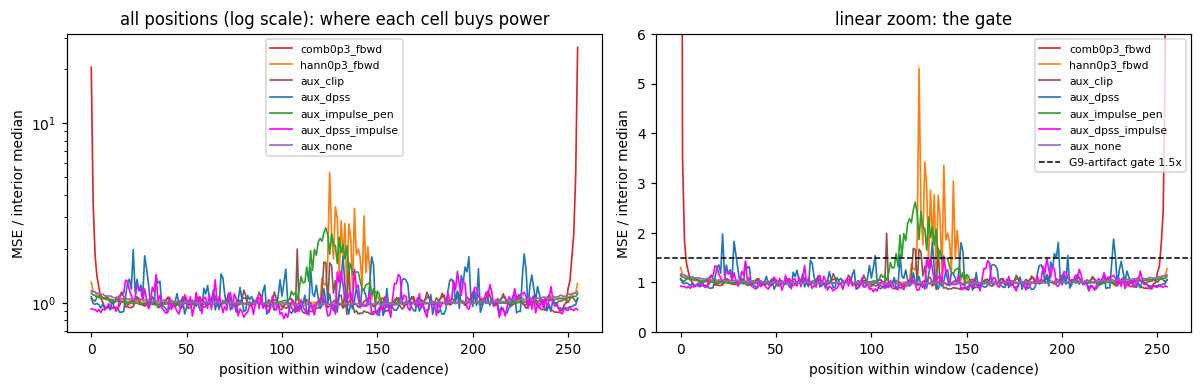

In [5]:
prof = pd.read_parquet(EXP / "exp09_impulse_profile.parquet")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for cell, colour in zip(order, ["tab:red", "tab:orange", "tab:brown", "tab:blue", "tab:green",
                                "magenta", "tab:purple"]):
    m = prof[prof.cell == cell].groupby("pos").mse.mean()
    m = m / np.median(m.loc[16:239])                       # normalise to each cell's own interior level
    for ax in axes:
        ax.plot(m.index, m.values, color=colour, lw=1.1, label=cell.replace("exp07_", "").replace("exp09_", ""))
axes[0].set_yscale("log"); axes[0].set_title("all positions (log scale): where each cell buys power")
axes[1].set_ylim(0, 6); axes[1].axhline(1.5, color="k", ls="--", lw=1, label="G9-artifact gate 1.5x")
axes[1].set_title("linear zoom: the gate")
for ax in axes:
    ax.set_xlabel("position within window (cadence)"); ax.set_ylabel("MSE / interior median")
    ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

Reading the panels (seed-averaged profiles, each normalised to its own interior level):

| curve | shape | what it means |
|---|---|---|
| `comb0p3` (red) | two narrow spikes, **only** at positions 0 and 255 | a rectangular FFT makes the edge the cheapest place to buy broadband power |
| `hann0p3` (orange) | flat at the edges, a tall ragged spike at ~110-150 | F27 drawn: the taper is exactly zero at the endpoints, so the cheapest position moved to the peak of the taper |
| `aux_impulse_pen` (green) | one **smooth, lower** bump over the same 110-150 band | the kurtosis penalty flattens the spike without moving it - the taper still says where |
| `aux_dpss` (blue) | **rough across the whole window**, no localised feature | the taper family removed the *address*: there is no single cheapest position left, so the error redistributes as broadband roughness rather than concentrating |
| `aux_dpss_impulse` (magenta) | lowest curve of the pressured arms, no localised feature | wave 2: both counter-measures at once. Section J prices what that bought |
| `aux_none` (purple) | flat at ~1.0 everywhere | nothing is buying spectral power because nothing is paying for it |

The blue curve is the one worth dwelling on: its argmax wanders 24-227 across seeds, so at this
resolution it reads as **the absence of a spike**. **Section D10 revises that** - the visual sign-off
found ~8 repeatable low bumps, and the argmax hops between them rather than landing freely. DPSS
removed the taper's preferred *position*; what it did to the *mechanism* is settled in D11, not here.

**A limit of this plot, quantified in J2.** These are *seed-averaged* profiles, and for the cells
whose leftover has no stable position (`aux_dpss`, `aux_dpss_impulse`) the average flattens six
differently-placed bumps into one low ridge: the child peaks at 1.53x here against a per-run
severity of 2.91x. For those cells this plot is a **lower bound**; the gate was always written on
the per-run `max_ratio`, so nothing reported is affected - but do not read the curve as the gate.

**What this does NOT say:** it does not say `aux_none` is the better model. Flatness here is the
absence of an objective, not the presence of a fix - section E prices it.

## D. Visual sign-off (REQUIRED) - the gate is not decided by the number alone

A summary statistic already fooled this project once: **F18 was retracted** after a ratio said the
edge defect was fixed while the impulse had merely moved. `G9-artifact` therefore reads:

```
  G9-artifact PASSES  iff  max_ratio <= 1.5  AND  a human has looked at fresh reconstructions
```

**One cell per label class**, so the check covers the physics rather than a few arbitrary stars. A
defect that only shows up on eclipsing binaries, or only on quiet stars, is invisible in a random
sample of three:

```
  QUIET   negative on ALL eight classification tasks
  v1      transit | eb | pulsating | rotation
  menu    ijspeert | osc_giant | solar_like_osc | rgb_vs_heb
```

**Each plot is a whole 4096-cadence segment, not a single window:**

```
  one segment = 16 windows x 256 cadences = 4096 cadences = 5.7 days = ONE training sequence
  each window is encoded and decoded INDEPENDENTLY, then the 16 decoded windows are laid end to end
  thin grey verticals mark the 15 window boundaries
```

This is the display convention that manufactures the **comb**: the objective never spans a boundary
(section A), so nothing penalises a discontinuity at a seam - but stitching the decoded windows for a
picture makes every seam visible at once. A jump at a grey line is *not* something the loss saw.
Looking at a full segment is the only way to judge whether an arm's impulse recurs **once per window**
(positional, what the gate measures) or lands only on particular stretches of the light curve.

| label | source |
|---|---|
| transit, eb, pulsating, rotation | `labels/variability_labels_star.csv` |
| osc_giant, solar_like_osc, rgb_vs_heb | `labels/new_task_labels_star.csv` |
| ijspeert | `labels/external/ijspeert2024_bright.csv` (TIC membership) |

The plots are **plotly, so they zoom**: box-select any stretch to inspect seams or the 110-150 centre
band at full resolution, double-click to reset, and click a legend entry to isolate one arm.

Sampling is **unseeded and advances on every call**, so re-running any single class cell draws a new
star *and* a new segment (7,658 segments over 2,021 test stars). Each plot is autoscaled to its own
star, and all arms within it share that scale, so an excursion is judged against that star's own
flux range.

In [6]:
import sys
sys.path.insert(0, str(ROOT / "src"))
from swm.models import WorldModel
import plotly.graph_objects as go

PACKED = EXP / "exp01_window256_seq16" / "packed"
WINDOW, SEG_WINDOWS = 256, 16              # 16 x 256 = 4096 cadences = one training sequence
ARMS = [RECT, REF, CLIP, "exp09_aux_dpss", "exp09_aux_impulse_pen", DI, "exp09_aux_none"]
COLOURS = {RECT: "#d62728", REF: "#ff7f0e", CLIP: "#8c564b", "exp09_aux_dpss": "#1f77b4",
           "exp09_aux_impulse_pen": "#2ca02c", DI: "#e377c2", "exp09_aux_none": "#9467bd"}

def load_model(cell, seed=0, device="cuda"):
    ck = "best_recon_only" if cell.startswith("exp09") else "best_recon_aux"
    blob = torch.load(EXP / cell / "models" / f"B_seed{seed}" / f"{ck}.pt",
                      map_location=device, weights_only=False)
    mc, cfg = blob["cfg"]["model"], blob["cfg"]
    m = WorldModel(in_ch=1, enc_channels=list(mc["enc_channels"]), kernel_size=int(mc["kernel_size"]),
                   z_dim=int(mc["z_dim"]), window=int(cfg["data"]["window"]),
                   gru_hidden=int(mc["gru_hidden"]), gru_layers=int(mc["gru_layers"]),
                   dyn_mode=str(mc.get("dyn_mode", "fwd"))).to(device)
    m.load_state_dict(blob["model"]); m.eval()
    return m

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODELS = {c: load_model(c, 0, DEVICE) for c in ARMS}

idx = pd.read_parquet(PACKED / "test_index.parquet"); idx["tic_id"] = idx["tic_id"].astype(int)
MM = np.memmap(PACKED / "test_windows.dat", dtype=np.float32, mode="r",
               shape=(int(idx["n_win"].sum()), WINDOW))

v1 = pd.read_csv(ROOT / "labels" / "variability_labels_star.csv"); v1["tic_id"] = v1.tic_id.astype(int)
nt = pd.read_csv(ROOT / "labels" / "new_task_labels_star.csv"); nt["tic_id"] = nt.tic_id.astype(int)
POS = {t: set(v1.loc[pd.to_numeric(v1[t], errors="coerce").fillna(0) == 1, "tic_id"])
       for t in ["transit", "eb", "pulsating", "rotation"]}
POS.update({t: set(nt.loc[pd.to_numeric(nt[t], errors="coerce").fillna(0) == 1, "tic_id"])
            for t in ["osc_giant", "solar_like_osc", "rgb_vs_heb"]})
POS["ijspeert"] = set(pd.read_csv(ROOT / "labels" / "external" / "ijspeert2024_bright.csv")["TIC"].astype(int))
ANY_POS = set().union(*POS.values())

RNG = np.random.default_rng()          # UNSEEDED and module-level: every call draws a new segment
# RNG = np.random.default_rng(0)       # uncomment for reproducible segments

def pick_segment(label):
    # random star carrying `label` (or carrying nothing, for QUIET), then a random segment of it,
    # then a random 16-window run inside that segment (segments hold 16 or 20 windows).
    tics = (set(idx.tic_id) - ANY_POS) if label == "QUIET" else (set(idx.tic_id) & POS[label])
    assert tics, f"no test-split star available for {label}"
    tic = int(RNG.choice(sorted(tics)))
    segs = idx[idx.tic_id == tic]
    seg = segs.iloc[int(RNG.integers(len(segs)))]
    off = int(RNG.integers(int(seg["n_win"]) - SEG_WINDOWS + 1))
    start = int(seg["row_start"]) + off
    return seg, np.array(MM[start:start + SEG_WINDOWS], dtype=np.float32)   # (16, 256)

def decode_strip(model, wins):
    # encode/decode each window INDEPENDENTLY, then lay the 16 decoded windows end to end
    with torch.no_grad():
        x = torch.from_numpy(wins).unsqueeze(-1).to(DEVICE)      # (16, 256, 1)
        mu, _ = model.encoder(x)
        rec = model.decoder(mu)[:, :, 0].cpu().numpy()            # (16, 256)
    return rec.reshape(-1)                                        # (4096,)

def plot_class(label, height=340):
    seg, wins = pick_segment(label)
    flux = wins.reshape(-1)                                       # (4096,)
    fig = go.Figure()
    fig.add_trace(go.Scatter(y=flux, mode="lines", name="input flux",
                             line=dict(color="black", width=0.9)))
    for cell in ARMS:
        fig.add_trace(go.Scatter(y=decode_strip(MODELS[cell], wins), mode="lines",
                                 name=cell.replace("exp07_", "").replace("exp09_", ""),
                                 line=dict(color=COLOURS[cell], width=0.7), opacity=0.9))
    for b in range(WINDOW, SEG_WINDOWS * WINDOW, WINDOW):          # 15 window boundaries
        fig.add_vline(x=b, line=dict(color="rgba(120,120,120,0.35)", width=0.5))
    fig.update_layout(
        height=height, width=1550, hovermode="x unified", margin=dict(t=52, b=38, l=55, r=12),
        title=dict(text=f"<b>{label}</b>  -  TIC {int(seg['tic_id'])}, sector {int(seg['sector'])}, "
                        f"segment {int(seg['seg_idx'])}  -  4096 cadences, grey lines = window seams",
                   font=dict(size=12)),
        legend=dict(orientation="h", y=1.14, x=0.5, xanchor="center", font=dict(size=9)),
        xaxis=dict(title="cadence within segment"), yaxis=dict(title="flux (MAD)"))
    return fig

print(f"ready: {len(MODELS)} arms on {DEVICE}; {len(idx)} segments over {idx.tic_id.nunique()} test stars")

ready: 7 arms on cuda; 7658 segments over 2021 test stars


### D1-D9. One class per cell - **re-run any cell for a new star and segment**

In [7]:
plot_class("QUIET")

In [8]:
plot_class("transit")

In [9]:
plot_class("eb")

In [10]:
plot_class("pulsating")

In [11]:
plot_class("rotation")

In [12]:
plot_class("ijspeert")

In [13]:
plot_class("osc_giant")

In [14]:
plot_class("solar_like_osc")

In [15]:
plot_class("rgb_vs_heb")

**What to look for, and what each observation would mean:**

**Per-arm, in every plot:**

| look at | what is reliably there | it means |
|---|---|---|
| **on** the grey seams | red (`comb0p3`) spiking at **every one of the 15 boundaries** | the pre-taper edge exploit, and note it is an **antisymmetric dipole** (down then up across the seam), exactly as exp07 pre-check C1 measured (-2.95 at p0, +5.11 at p255) |
| **between** the seams | orange (`hann0p3`) spiking near the **middle of every window**, offset ~128 cadences from the grey lines | F27's relocation, in a raw reconstruction rather than a summary statistic |
| blue (`aux_dpss`) | wiggles spread across each window, no repeating feature | error redistributed rather than concentrated |
| green (`aux_impulse_pen`) | a small bump near each window centre | the kurtosis penalty lowers the spike without moving it |
| purple (`aux_none`) | a **near-flat trace** tracking only the slow envelope | the low-pass shortcut in its most extreme form |

**What the full segment shows that a single window cannot - and it sharpens F27.** Both red and
orange form a **regular train, one spike per 256 cadences**. They differ only in phase:

```
  comb0p3   spike ON  the seam        (rectangular FFT: the endpoints are cheapest)
  hann0p3   spike MID-window          (Hann taper: its peak is cheapest)
  both      period = 256 cadences  ->  BOTH manufacture a comb in a stitched strip, at the SAME
                                       fundamental. The taper changed the comb's PHASE, not its
                                       periodicity.
```

That is the picture behind a number that has otherwise looked odd: the 6-seed comb contrast is
**Hann 26.6 vs rectangular 20.4** - the taper is slightly *worse* on that metric, not better. It was
never removing the periodic train; it was moving where in the window the train sits.

**And it is not a defect the objective can see.** Section A: no loss term spans a boundary. A jump at
a grey line was never penalised and never rewarded - which is exactly why the comb is a display
artifact while the within-window impulse is the real exploit.

**Across panels - what the nine classes are for.** The gate is a single number averaged over every
test window, so it cannot tell you *which stars* an arm fails on. These are the readings a per-class
view can produce that the ratio cannot:

```
  defect appears on QUIET but not on variables   ->  severity is being judged against a tiny interior
                                                     error; the F23 / placebo-control pathology again
  defect appears only on eb / ijspeert           ->  the impulse is tracking real eclipse edges, i.e.
                                                     it is partly SIGNAL and killing it costs the task
  defect appears on every class equally          ->  genuinely position-driven, not physics-driven
                                                     (this is what the gate assumes)
  an arm reconstructs pulsating but not eb       ->  a band-selective failure the scalar gate hides
```

Zoom into positions 0-10 and 245-255 for the edge story, and 110-150 for the centre story.

Two honest observations that the gate numbers do not carry:

```
  1. purple is not "smooth" - it is nearly CONSTANT. Best reconstruction MSE is bought by predicting
     almost nothing, which is exactly what the aux term exists to prevent.
  2. NONE of the arms track the input's high-frequency structure well. The black trace is far rougher
     than every reconstruction. This is a limitation of the model, not of exp09, and it is worth
     stating plainly rather than cropping out.
```

If purple looks *best* to the eye, that is the trap this whole notebook is about: it has the lowest
reconstruction error and the worst probe score (section E).

### D10. What the sign-off found - and what it cost the `aux_dpss` verdict

**The observation (user, 2026-08-16).** Three arms have unambiguous spikes: `comb0p3` on the two
edges, `hann0p3` a ragged spike at the centre, `aux_impulse_pen` a smooth bell at the centre.
`aux_dpss` is the ambiguous one: no tall spike, but **~8 wide, low bumps** at approximately

```
  cadence   25   70   100   120   140   160   200   230        width 20-30 cadences each
```

That is a claim the gate cannot make or refute: `max_ratio` is one number per run, so a tall spike and
a train of low bumps with the same maximum are indistinguishable to it. Two hypotheses follow, and
they have opposite consequences for whether the 1.5x bar is even the right instrument here.

In [16]:
from scipy.signal import find_peaks
from scipy.signal.windows import dpss as _dpss

USER_BUMPS = [25, 70, 100, 120, 140, 160, 200, 230]

# H1: the decoder buys power where the DPSS taper FAMILY has most weight (the Hann mechanism, x7)
tap = _dpss(256, NW=4.0, Kmax=7, sym=True)              # exactly the family aux_dpss trains under
weight = (tap ** 2).sum(axis=0)                          # aggregate multitaper weight per position
lobes, _ = find_peaks(weight, prominence=0.002)
print("H1 - DPSS aggregate weight sum_k taper_k(t)^2, local maxima:", lobes.tolist())

prof = pd.read_parquet(EXP / "exp09_impulse_profile.parquet")
def norm_profile(cell):
    m = prof[prof.cell == cell].groupby("pos").mse.mean()
    return (m / np.median(m.loc[16:239])).values
dp = norm_profile("exp09_aux_dpss")
print("   rho(weight, aux_dpss profile) over interior:",
      f"{spearmanr(weight[16:240], dp[16:240]).statistic:+.3f}")
for c in ["exp07_hann0p3_fbwd", "exp09_aux_impulse_pen"]:
    print(f"   control rho for {c:24s}: {spearmanr(weight[16:240], norm_profile(c)[16:240]).statistic:+.3f}")

# H2: the residual sits on the DECODER's own granularity (4x ConvTranspose1d(k=4,s=2) = 16x upsample
#     from a 16-position bottleneck, so each latent position governs a 16-cadence patch)
print("\nH2 - spatial periodicity of the profile (interior, cubic-detrended, per seed then averaged)")
print(f"  {'cell':24s} {'top periods':30s} {'power@16':>9s} {'power@8':>8s}")
for c in ["exp07_comb0p3_fbwd", "exp07_hann0p3_fbwd", CLIP, "exp09_aux_dpss",
          "exp09_aux_impulse_pen", DI, "exp09_aux_none"]:
    g = prof[prof.cell == c]
    specs = []
    for s in sorted(g.seed.unique()):
        m = g[g.seed == s].sort_values("pos").mse.values[16:240].astype(float)
        m = m / np.median(m)
        m = m - np.polyval(np.polyfit(np.arange(len(m)), m, 3), np.arange(len(m)))
        specs.append(np.abs(np.fft.rfft(m * np.hanning(len(m)))) ** 2)
    P = np.mean(specs, axis=0); P[0] = 0
    freqs = np.fft.rfftfreq(224, d=1.0)
    per = np.divide(1.0, freqs, out=np.full_like(freqs, np.inf), where=freqs > 0)
    pw = lambda t: P[int(np.argmin(np.abs(per - t)))] / P.sum()
    top = [round(float(per[i]), 1) for i in np.argsort(P)[::-1][:4]]
    print(f"  {c:24s} {str(top):30s} {pw(16):9.4f} {pw(8):8.4f}")

H1 - DPSS aggregate weight sum_k taper_k(t)^2, local maxima: [27, 127, 228]
   rho(weight, aux_dpss profile) over interior: +0.195
   control rho for exp07_hann0p3_fbwd      : -0.013
   control rho for exp09_aux_impulse_pen   : +0.240

H2 - spatial periodicity of the profile (interior, cubic-detrended, per seed then averaged)
  cell                     top periods                     power@16  power@8
  exp07_comb0p3_fbwd       [8.0, 4.0, 2.0, 8.3]              0.0119   0.2664
  exp07_hann0p3_fbwd       [74.7, 56.0, 44.8, 37.3]          0.0165   0.0047
  exp09_aux_clip           [44.8, 112.0, 37.3, 74.7]         0.0137   0.0146
  exp09_aux_dpss           [8.0, 16.0, 4.0, 14.9]            0.0458   0.0633
  exp09_aux_impulse_pen    [74.7, 112.0, 56.0, 44.8]         0.0038   0.0026
  exp09_aux_dpss_impulse   [32.0, 8.0, 37.3, 74.7]           0.0147   0.0502
  exp09_aux_none           [2.0, 4.0, 8.0, 2.0]              0.0029   0.1173


**H1 is rejected.** The aggregate DPSS weight has only **three** local maxima (27, 127, 228). Three of
the eight reported bumps sit on them (offsets <= 7); the other five are 13-43 cadences away. And
`rho(weight, profile)` = **+0.195**, *lower* than `aux_impulse_pen`'s +0.240 - a cell that never saw a
DPSS taper. The bumps are not the taper family's lobes.

**H2 is supported.** `aux_dpss` is the only cell where **period 16** is a leading spatial component
(power 0.046, 3-12x every other cell). 16 cadences is exactly one bottleneck position: the decoder is
`4x ConvTranspose1d(kernel=4, stride=2)`, a 16x upsample from a 16-position latent. The spiky arms are
dominated by *low* frequencies instead (74.7, 56.0, 44.8) - that is their single broad centre hump.

**Correction to this notebook's earlier reading.** Section C said DPSS "destroyed the address" because
the per-seed argmax wanders 24-227. That was wrong. DPSS destroyed the **taper-imposed** address, and
the residual reorganised onto the **decoder's own granularity**. The argmax is not wandering freely -
it hops between repeating patch-scale bumps, which is what the eye saw and the scalar could not.

**Wave 2 adds a clean contrast here.** `aux_dpss_impulse` trains under the same DPSS family, yet its
leading periods are [32.0, 8.0, 37.3, 74.7] and its period-16 power is **0.0147** - a third of
`aux_dpss`'s 0.0458, and no higher than the cells that never saw a DPSS taper. So the decoder-
granularity roughness is not an inevitable consequence of the taper family: adding the kurtosis
penalty removes that signature too. Whatever the child's leftover is, it is not the patch-scale
comb, which is one more reason its residual reads as ordinary error rather than as structure.

That leaves the question the gate cannot answer: are those bumps still the decoder **buying** log-PSD
power, merely distributed - or **honest residual** that a dominant impulse used to mask? Only the
second would mean the 1.5x bar is the wrong instrument for this cell.

### D11. Purchase or honest residual? - exp07 pre-check C1, generalised

C1 forced the **edge** residual to zero and found log-PSD **rose +237..+348%** while time-MSE *fell*
11-17%: the spike was not fidelity, it was spectral currency. The same operation, applied wherever the
error actually concentrates:

```
  ablate(positions):  recon[positions] := target[positions]        (residual forced to zero)
                      then recompute the cell's OWN training objective

  time-MSE MUST fall  -> sanity check, not a result
  log-PSD is the readout:
        asymmetry = (rise at top-error positions) / (rise at RANDOM positions)
        asymmetry >> 1  ->  PURCHASE          (DPSS only redistributed the exploit)
        asymmetry ~  1  ->  HONEST RESIDUAL   (DPSS closed the channel; 5.28x measures granularity)
```

Two controls, both required:

| control | cell | what it must do |
|---|---|---|
| positive | `comb0p3_fbwd` | reproduce C1's 27-38x location asymmetry, or the method is broken |
| negative | `aux_none` | sit at ~1: with no spectral term there is nothing to buy |
| baseline | random positions | same count, same cell, 5 draws - this is C1's location-asymmetry design |

Every cell is scored under **its own training taper**, since the question is whether it was buying
power in the term it actually optimised.

In [17]:
ab = pd.read_csv(EXP / "exp09_bump_ablation.csv")
agg = ab.groupby(["cell", "budget"]).agg(
    bump=("d_log_psd_bump_pct", "mean"), bump_sd=("d_log_psd_bump_pct", "std"),
    rand=("d_log_psd_rand_pct", "mean"), time_mse=("d_time_mse_bump_pct", "mean"),
    edge=("edge_selected", "mean"))
agg["asymmetry"] = agg.bump / agg.rand
ORDER = ["exp07_comb0p3_fbwd", "exp07_hann0p3_fbwd", CLIP, "exp09_aux_impulse_pen",
         "exp09_aux_dpss", DI, "exp09_aux_none"]
piv = agg.reset_index().pivot(index="cell", columns="budget", values="asymmetry").loc[ORDER]
print("ASYMMETRY (log-PSD rise at top-error positions / at random positions), by ablation budget")
print(piv.round(2).to_string())

b2 = agg.xs(2, level="budget")
# PROTOCOL GATE: the positive control must reproduce C1, and must have selected an ENDPOINT
assert b2.loc["exp07_comb0p3_fbwd", "edge"] == 1.0, \
    "comb0p3 did not select a window endpoint - the find_peaks endpoint-padding fix has regressed"
assert 20 <= b2.loc["exp07_comb0p3_fbwd", "asymmetry"] <= 60, \
    f"positive control off C1's 27-38x: {b2.loc['exp07_comb0p3_fbwd', 'asymmetry']:.1f}"
assert b2.loc["exp09_aux_none", "asymmetry"] < 1.1, "negative control is not at the honest-residual floor"
print(f"\nprotocol gate OK: comb0p3 asymmetry {b2.loc['exp07_comb0p3_fbwd','asymmetry']:.1f}x "
      f"(C1 published 27-38x), log-PSD rise {b2.loc['exp07_comb0p3_fbwd','bump']:+.0f}% (C1 +237..+348%)")
print(f"honest-residual floor from aux_none: {b2.loc['exp09_aux_none','asymmetry']:.2f}")
print("\ntime-MSE change at the ablated positions (must be negative everywhere):")
print(b2[["bump", "rand", "time_mse"]].loc[ORDER].round(2).to_string())

ASYMMETRY (log-PSD rise at top-error positions / at random positions), by ablation budget
budget                     2      6     20    40
cell                                            
exp07_comb0p3_fbwd      34.40  11.43  3.32  1.83
exp07_hann0p3_fbwd      12.31   5.52  2.38  1.50
exp09_aux_clip          17.39   5.68  1.93  1.41
exp09_aux_impulse_pen    3.87   3.47  1.90  1.27
exp09_aux_dpss           3.47   2.73  1.76  1.35
exp09_aux_dpss_impulse   1.94   1.89  1.53  1.29
exp09_aux_none           0.01   0.98  1.00  1.00

protocol gate OK: comb0p3 asymmetry 34.4x (C1 published 27-38x), log-PSD rise +291% (C1 +237..+348%)
honest-residual floor from aux_none: 0.01

time-MSE change at the ablated positions (must be negative everywhere):
                          bump   rand  time_mse
cell                                           
exp07_comb0p3_fbwd      291.44   8.47    -14.79
exp07_hann0p3_fbwd      167.51  13.61     -6.08
exp09_aux_clip           90.56   5.21     -2.66
exp09_aux_im

**Outcome (i): still a purchase.** `aux_dpss` sits at **3.5x** at budget 2 - unambiguously above the
**~1.0** honest-residual floor that `aux_none` defines, and far below the frozen recipe's 12.3x.

```
  purchase strength   34.4x (rect)  ->  12.3x (Hann)  ->  3.5x (DPSS)  ->  0.01x (no aux term)
  probe outcome       ------------- all fine ----------------------->  ->  REGRESSES
```

**So the 1.5x bar is the right instrument after all**, and section C's verdict stands on mechanism
rather than on a threshold. DPSS cuts the purchase ~3.5x below Hann and ~10x below rectangular - the
largest reduction any counter-measure achieved *while keeping the probe* - but **the only arm that
reaches the honest-residual floor is the one that fails G9-noregress.** The trade-off is now
demonstrated at the level of the mechanism, not just the outcome.

`aux_impulse_pen` (3.9x) and `aux_dpss` (3.5x) land in the same place from opposite directions - one
suppressing local peakiness, the other removing the taper's preferred address. Neither alone
approaches the floor, which was the honest argument for trying them **combined** in a second wave.

**That wave ran, and this is the row where it did best.** `aux_dpss_impulse` reaches **1.94x** at
budget 2 - below both parents and the closest any probe-preserving cell has come to the 1.0 floor.
Section J shows why that does not translate into a G9-artifact pass: the purchase composed, the
bump height did not.

**Two methodological traps this test hit, recorded because both would silently invert a verdict:**

```
  1. scipy.find_peaks CANNOT return an endpoint (index 0 and 255 have one neighbour each).
     An unpadded call skipped the rectangular recipe's edge impulse entirely -- the project's
     strongest known purchase then scored 0.73, BELOW its own random control. The profile is now
     padded with a below-minimum sentinel, and `edge_selected` is asserted in-cell.

  2. Budget dilutes asymmetry. Ablating 40 of 256 cadences moves the random control by +63..+88%,
     which compresses every ratio toward 1: Hann read 1.53 at budget 40 against 12.3 at budget 2.
     C1 ablated ~2 positions. The budget is swept and the verdict is read where the control is small.
```

## E. G9-noregress - does closing the channel cost the representation?

```
  delta(cell, task) = mean over 6 seeds of [ PR-AUC(cell, seed) - PR-AUC(hann0p3_fbwd, seed) ]
  SE                = sd(per-seed differences) / sqrt(6)          (paired - seed variation cancels)
  gate: FAIL if delta < -2*SE on ANY of the four v1 tasks, at EITHER readout
```

**Readouts** (roadmap D2): `mean` is the headline, `mean_std` the second. `mean` is plain
mean-pooling of a star's window latents; `mean_std` concatenates the per-dimension mean and standard
deviation, so it can see dispersion across windows as well as level.

**Decision rule:** this gate exists to stop "clean but useless" from being recorded as a success.

In [18]:
new = probe_scores("ro")[["cell", "seed", "pooling", "task", "pr_auc"]]
e7 = pd.read_csv(EXP / "exp07_aux_gap_6seed.csv")
ref = e7[(e7.arm == "trained") & (e7.cell == REF)][["cell", "seed", "pooling", "task", "pr_auc"]]
unt = e7[e7.arm == "untrained"].copy(); unt["cell"] = "untrained_w256"
sc = pd.concat([new, ref], ignore_index=True)

out = []
for pooling in ["mean", "mean_std"]:
    for c in EXP09:
        row = {"pooling": pooling, "cell": c}
        fails = []
        for t in TASKS:
            a = sc[(sc.cell == c) & (sc.task == t) & (sc.pooling == pooling)].set_index("seed").pr_auc
            b = sc[(sc.cell == REF) & (sc.task == t) & (sc.pooling == pooling)].set_index("seed").pr_auc
            d = (a - b).dropna(); se = d.std(ddof=1) / np.sqrt(len(d))
            row[t] = f"{d.mean():+.4f}{'*' if abs(d.mean()) > 2 * se else ' '}"
            if d.mean() < -2 * se:
                fails.append(t)
        row["G9_noregress"] = "PASS" if not fails else "FAIL: " + ",".join(fails)
        out.append(row)
print(pd.DataFrame(out).to_string(index=False))
print("\n(* = clears 2*SE.  Absolute PR-AUC, 6-seed mean, pooling=mean:)")
piv = pd.concat([sc, unt], ignore_index=True)
piv = piv[piv.pooling == "mean"].pivot_table(index="cell", columns="task", values="pr_auc", aggfunc="mean")
print(piv.reindex([REF] + EXP09 + ["untrained_w256"])[TASKS].round(4).to_string())

 pooling                   cell       eb pulsating rotation  transit                G9_noregress
    mean         exp09_aux_none +0.0069   -0.0266  -0.0154* -0.0074               FAIL: rotation
    mean         exp09_aux_dpss +0.0028   +0.0046  -0.0067  -0.0013                         PASS
    mean  exp09_aux_impulse_pen +0.0027   -0.0054  +0.0007  +0.0005                         PASS
    mean         exp09_aux_clip +0.0129*  -0.0066  +0.0055  -0.0135*               FAIL: transit
    mean exp09_aux_dpss_impulse +0.0019   -0.0033  +0.0015  +0.0021                         PASS
mean_std         exp09_aux_none -0.0162*  -0.0315* -0.0256* -0.0105  FAIL: eb,pulsating,rotation
mean_std         exp09_aux_dpss -0.0075   +0.0005  +0.0109  -0.0068                         PASS
mean_std  exp09_aux_impulse_pen +0.0012   -0.0088  -0.0021  -0.0054                         PASS
mean_std         exp09_aux_clip -0.0066*  -0.0170  +0.0188  -0.0133                     FAIL: eb
mean_std exp09_aux_dpss_impuls



(* = clears 2*SE.  Absolute PR-AUC, 6-seed mean, pooling=mean:)
task                        eb  pulsating  rotation  transit
cell                                                        
exp07_hann0p3_fbwd      0.7710     0.8053    0.5593   0.1441
exp09_aux_none          0.7779     0.7787    0.5439   0.1367
exp09_aux_dpss          0.7738     0.8099    0.5526   0.1428
exp09_aux_impulse_pen   0.7737     0.7999    0.5599   0.1447
exp09_aux_clip          0.7840     0.7987    0.5648   0.1306
exp09_aux_dpss_impulse  0.7729     0.8020    0.5607   0.1462
untrained_w256          0.7124     0.7683    0.5315   0.0805


**The trade-off, stated plainly:**

```
  aux_none        artifact 1.17x  PASS   |  probe REGRESSES (rotation, and eb+pulsating at mean_std)
  aux_dpss        artifact 5.28x  fail   |  probe holds (pulsating dead level: +0.005)
  aux_impulse_pen artifact 3.08x  fail   |  probe holds
  aux_clip        artifact 4.76x  fail   |  probe REGRESSES (transit; eb at mean_std)
  aux_dpss_impulse artifact 2.91x fail   |  probe holds (wave 2; best `mean` delta of the ladder)
  ------------------------------------------------------------------------------------------
  NO cell passes BOTH gates - now across FIVE independent attempts, not three.
```

The impulse and the probe benefit come from the same source - spectral pressure. Removing the term
removes the impulse *and* the benefit; fighting the impulse while keeping the term buys 3-5x instead
of 11.8x but never 1.5x.

This also settles her "baseline 1" at a **fair rung** for the first time: `experiments/exp03_fb0_b0p1_none`
is 1 seed / 60 epochs / a different selection rule / lambda 1, and must never be quoted as baseline 1.

## F. Y0 + G9-select - her causal claim, tested directly

Two limbs, pre-registered separately because they can disagree:

```
  limb (a)  DETECTOR    val/recon alone separates collapsed runs from trained ones
  limb (b)  MECHANISM   among the survivors, the loss then ranks representations
```

**Sign convention - this is the whole result, so it is stated before the number:**

```
  rho_project = -spearman( val/recon , probe score )
  rho > 0  ->  LOWER loss predicts HIGHER probe  ->  the loss is a usable selector
  rho < 0  ->  ANTI-selection: picking the lowest loss picks the worst representation
```

The cell below first **reproduces the published F11 baseline** (-0.58 / -0.70 / -0.84 / -0.59) with
this same estimator, as a protocol gate, before any new number is believed.

In [19]:
CELLS05 = ["exp05_comb_off"] + [f"exp05_comb_{d}_c{c}" for d in ("fwd", "fbwd", "multi")
                                for c in ("0p1", "0p3", "1p0")]
s05 = []
for c in CELLS05:
    d = pd.read_csv(EXP / c / "results" / "readout_sweep.csv")
    d = d[(d.readout == "logistic") & (d.pooling == "mean")]; d["cell"] = c
    s05.append(d[["cell", "seed", "task", "pr_auc"]])
s05 = pd.concat(s05, ignore_index=True)
r05 = []
for f in glob.glob(str(EXP / "exp05_forensics" / "curves_exp05" / "*.csv")):
    n = pathlib.Path(f).stem
    if n == "runs_manifest" or "killedprefix" in n:
        continue
    c, _, s = n.rpartition("_B_seed")
    if c in CELLS05:
        r05.append({"cell": c, "val_recon": pd.read_csv(f)["val/recon"].min()})
rec05 = pd.DataFrame(r05).groupby("cell").val_recon.mean()

PUB = {"transit": -0.576, "eb": -0.697, "pulsating": -0.842, "rotation": -0.588}
print("PROTOCOL GATE - reproduce F11 with this estimator")
for t in TASKS:
    p = s05[s05.task == t].groupby("cell").pr_auc.mean()
    j = pd.concat([rec05.rename("r"), p.rename("p")], axis=1).dropna()
    got = -spearmanr(j.r, j.p).statistic
    assert abs(got - PUB[t]) < 0.06, f"F11 does not reproduce for {t}: {got:.3f} vs {PUB[t]}"
    print(f"  {t:10s} rho {got:+.3f}   published {PUB[t]:+.3f}   OK")

PROTOCOL GATE - reproduce F11 with this estimator
  eb         rho -0.697   published -0.697   OK
  pulsating  rho -0.842   published -0.842   OK
  rotation   rho -0.588   published -0.588   OK
  transit    rho -0.576   published -0.576   OK


In [20]:
# frozen-recipe population: exp08 ladder + the two exp07 ends + the three exp09 cells
COLS = ["cell", "seed", "pooling", "task", "pr_auc"]
parts = [pd.read_csv(EXP / p)[COLS] for p in
         ["exp08_diag_probe_summary.csv", "exp08_diag_lo_probe_summary.csv"]] + [probe_scores("ro")[COLS]]
ends = e7[(e7.arm == "trained") & (e7.cell.isin(["exp07_hann0p3_off", REF]))][
    ["cell", "seed", "pooling", "task", "pr_auc"]]
allsc = pd.concat(parts + [ends], ignore_index=True).drop_duplicates(["cell", "seed", "pooling", "task"])
allsc = allsc[~allsc.cell.str.startswith("untrained")]

rows = []
for sub in ["exp07", "exp08", "exp09"]:
    for f in glob.glob(str(EXP / f"{sub}_forensics" / f"curves_{sub}" / "*.csv")):
        n = pathlib.Path(f).stem
        if n == "runs_manifest" or "killedprefix" in n:
            continue
        c, _, s = n.rpartition("_B_seed")
        rows.append({"cell": c, "val_recon": pd.read_csv(f)["val/recon"].min(),
                     "n_active": pd.read_csv(f).tail(10)["val/n_active_units"].mean()})
cur = pd.DataFrame(rows)
cur = cur[cur.cell.isin(allsc.cell.unique())]
recon = cur.groupby("cell").val_recon.mean(); active = cur.groupby("cell").n_active.mean()

COLLAPSED = ["exp08_smooth", "exp08_smooth_half"]        # independently identified: n_active == 1
THRESH = 1.10
flagged = sorted(recon[recon > THRESH].index)
print("limb (a) DETECTOR")
print(f"  threshold val/recon > {THRESH}")
print(f"  flagged                 : {flagged}")
print(f"  independently collapsed : {sorted(COLLAPSED)}")
print(f"  EXACT MATCH             : {flagged == sorted(COLLAPSED)}")
print(f"  margin: highest kept {recon.drop(COLLAPSED).max():.3f} | lowest flagged {recon[COLLAPSED].min():.3f}")
assert flagged == sorted(COLLAPSED), "the label-free detector no longer isolates exactly the collapsed cells"

limb (a) DETECTOR
  threshold val/recon > 1.1
  flagged                 : ['exp08_smooth', 'exp08_smooth_half']
  independently collapsed : ['exp08_smooth', 'exp08_smooth_half']
  EXACT MATCH             : True
  margin: highest kept 0.987 | lowest flagged 1.299


In [21]:
# limb (b) MECHANISM.  rho_project = -spearman(val/recon, PR-AUC)  ->  POSITIVE = usable selector.
# Three NESTED populations, read left to right as one narrative:
#   ALL         every cell carrying both a loss curve and a probe score              n=13
#   -collapsed  ...minus the 2 latent-collapsed cells AND the 5 exp09 cells
#               = the population exactly as it stood BEFORE exp09                    n=6
#   +exp09      ...with the 5 exploit-closed cells added back                        n=11  <- G9-select
# The middle column drops exp09 as well as the collapsed pair, so it is a RUNG OF A LADDER, not a
# one-variable ablation of the first column. F1-F3 below show the cells and points behind every entry.
POPS = ["ALL", "-collapsed", "+exp09"]


def populations(task, pooling):
    """name -> frame indexed by cell with r = val/recon (6-seed mean), p = PR-AUC (6-seed mean)."""
    p = allsc[(allsc.task == task) & (allsc.pooling == pooling)].groupby("cell").pr_auc.mean()
    j = pd.concat([recon.rename("r"), p.rename("p")], axis=1).dropna()
    keep = j.drop(index=[c for c in COLLAPSED if c in j.index])
    base = keep.drop(index=[c for c in EXP09 if c in keep.index])
    return dict(zip(POPS, [j, base, keep]))


rows = []
for pooling in ["mean", "mean_std"]:
    for t in TASKS:
        row = {"pooling": pooling, "task": t}
        for name, sub in populations(t, pooling).items():
            res = spearmanr(sub.r, sub.p)
            row[name], row[f"p({name})"] = -res.statistic, res.pvalue
        rows.append(row)
sel = pd.DataFrame(rows).set_index(["pooling", "task"])
sel = sel[[c for pair in zip(POPS, [f"p({p})" for p in POPS]) for c in pair]]

# How large would |rho| have to be, at these n, before it meant anything?  t = rho*sqrt((n-2)/(1-rho^2))
ns = {n: sorted({len(populations(t, pl)[n]) for t in TASKS for pl in ["mean", "mean_std"]})
      for n in POPS}
assert all(len(v) == 1 for v in ns.values()), f"population size varies by task: {ns}"
ns = {k: v[0] for k, v in ns.items()}
crit = pd.DataFrame({"n cells": pd.Series(ns)})
tc = tdist.ppf(0.975, crit["n cells"] - 2)
crit["|rho| for p<0.05"] = tc / np.sqrt(crit["n cells"] - 2 + tc ** 2)
crit["largest |rho| seen"] = [sel[c].abs().max() for c in POPS]

display(sel.style
        .format({**{c: "{:+.3f}" for c in POPS}, **{f"p({c})": "{:.2f}" for c in POPS}})
        .background_gradient(cmap="RdYlGn", vmin=-.6, vmax=.6, subset=POPS)
        .set_caption("G9-select: rho_project, all 4 v1 tasks x both readouts x 3 populations"))
display(crit.round(3).style.set_caption("...and the bar every one of those numbers has to clear"))


,n cells,|rho| for p<0.05,largest |rho| seen
ALL,13,0.553000,0.478000
-collapsed,6,0.811000,0.429000
+exp09,11,0.602000,0.473000


**Limb (a) PASSES, exactly.** A threshold on `val/recon` flags precisely the two cells we independently
call collapsed, with no overlap. **A label-free failure detector exists** - this part of her advice is
real and usable.

But note the margin **narrows once exp09 joins the population**: highest kept moves 0.916 -> **0.987**
against the flagged 1.299, so the gap falls from 1.42x to 1.32x. The cell responsible is now
`aux_dpss_impulse` (with `aux_dpss` just behind at 0.981) - a cell that is *healthy* (it passes
G9-noregress on both readouts and posts the ladder's best `mean` delta) yet carries the highest
reconstruction loss of any non-collapsed cell. Each wave of counter-measures has pushed this margin
further down, which is the trend to watch rather than the current value. That is the failure mode a fixed threshold will
eventually hit: **a good model with a deliberately harder objective looks like a broken one.** The
detector separates *catastrophic collapse* from *everything else*; it is not a quality scale.

**Limb (b) FAILS, and the reason inverts the intuition:**

```
  ALL cells        rho > 0    the loss looks like a working selector
  - collapsed      rho < 0    anti-selection returns
       -->  the collapsed runs were MASKING the problem, not causing it
       -->  they are catastrophically bad on BOTH axes, which flatters the correlation
```

**G9-select FAILS.** Adding the five exploit-closed cells makes rho *more* negative in 5 of 8
task x readout combinations (and the three that move the other way stay far from significance). The mechanism is visible in the loss column itself:

```
  aux_none   LOWEST val/recon (0.767)  -->  the cell that FAILED G9-noregress
  aux_dpss   HIGHEST val/recon (0.98)  -->  the cell with the best pulsating score
  aux_dpss_impulse  0.99               -->  and the best `mean` v1 delta of the whole ladder
```

The exploit-closed cells **reproduce** the anti-correlation instead of breaking it.

**What this does NOT say.** It does not say her reasoning was wrong - the exploit is real and exp07's
C1 measured it directly. It says the exploit is **not the cause of the void**. That is the
pre-registered P4 outcome: *the void survives its most obvious explanation*, which is a stronger
negative result than the one we had.

**Caveats, on the record:** n = 6 / 11 / 13 cells, so every p-value in the table is
0.10-0.87 - the *sign flip* is the finding, not the magnitude. F3 makes the weaker
statement explicit: **not one entry in any column clears the bar for p<0.05**, so nothing
here is evidence that the loss ranks representations *in either direction*. And the comparison against exp05's rectangular rho changes three things at
once (recipe, swept axis, seed count), so only the internally-controlled columns above are trustworthy.

### F1. The population behind those numbers

A rank correlation over 13 points is worth exactly as much as the 13 points. Every entry in the
table above is computed over the rows below - one cell per row, each value a 6-seed mean.

```
  group      why the cell is in this group
  ---------  ---------------------------------------------------------------
  base       trained before exp09: the exp08 dynamics ladder + the two exp07 ends
  exp09      one of the 5 exploit-closed cells this experiment added
  collapsed  independently flagged by  val/n_active_units == 1  (NOT by its loss)
```

**Read the `group` column against the sort order (ascending `val/recon`).** If the loss ranked
representations, the PR-AUC columns would fall monotonically down each column. State that before
looking: *monotone decrease -> the loss is a selector; no ordering -> it is not.*


In [22]:
# F1. The whole population, every task, both readouts - the raw material of every rho in the table.
grp = pd.Series("base", index=recon.index)
grp[[c for c in EXP09 if c in grp.index]] = "exp09"
grp[[c for c in COLLAPSED if c in grp.index]] = "collapsed"

pop = pd.concat([grp.rename(("", "group")), recon.rename(("", "val/recon")),
                 active.rename(("", "n_active"))], axis=1)
for pooling in ["mean", "mean_std"]:
    piv = allsc[allsc.pooling == pooling].pivot_table(index="cell", columns="task",
                                                      values="pr_auc", aggfunc="mean")[TASKS]
    piv.columns = pd.MultiIndex.from_product([[f"PR-AUC {pooling}"], TASKS])
    pop = pop.join(piv)
pop = pop.dropna().sort_values(("", "val/recon"))
pop.columns = pd.MultiIndex.from_tuples(pop.columns)
assert len(pop) == ns["ALL"], "the table and the ALL population disagree on membership"

sc_cols = [c for c in pop.columns if c[0].startswith("PR-AUC")]
display(pop.style
        .format({("", "val/recon"): "{:.3f}", ("", "n_active"): "{:.1f}",
                 **{c: "{:.3f}" for c in sc_cols}})
        .background_gradient(cmap="Blues", subset=sc_cols, axis=0)
        .background_gradient(cmap="Oranges", subset=[("", "val/recon")])
        .set_caption("sorted by val/recon, ascending - if the loss were a selector, "
                     "every PR-AUC column would decrease downwards"))


**The ordering is not there, on any of the 8 columns.** The best `val/recon` in the whole population
(`aux_none`, 0.766) is the cell that FAILED G9-noregress; the two worst non-collapsed cells
(`aux_dpss` 0.981, `aux_dpss_impulse` 0.987) carry the ladder's best `pulsating` and best `mean` v1
delta. Within the 11 healthy cells the loss spans 0.766-0.987 (+29%) while `eb` moves over
0.737-0.784 with no relation to it.

**Where the positive `ALL` column comes from, in one line.** The two collapsed cells sit at
`val/recon` 1.30 - a third above every other cell - *and* at `eb` 0.61, which is **0.127 below the
worst healthy cell** while the healthy 11 span only **0.047** end to end. Two points that are extreme
on both axes at once will produce a positive rank correlation no matter what the other 11 do.

**What this does NOT say.** It does not say the collapsed cells are bad data - limb (a) is exactly
the claim that flagging them from the loss alone *works*. It says detecting catastrophe and ranking
quality are two different jobs, and only the first one is being done.

**One column deliberately included as a negative control:** `n_active`. `exp08_frozen` carries 97
active latent units against `hann0p3`'s 5.8, and lands mid-table on both loss and every probe -
latent width is not what `val/recon` is tracking either.


### F1b. The same population as a delta against the frozen recipe

F1 answers *how good*; the question this section actually asks is *better or worse than the recipe we
froze*. Same 13 cells, same 8 columns, expressed as a **paired** difference against `hann0p3_fbwd`:

```
  delta(cell, task, readout) = mean over the 6 seeds of [ PR-AUC(cell, seed) - PR-AUC(REF, seed) ]
  SE                         = std(those 6 differences, ddof=1) / sqrt(6)
  bold                       = |delta| > 2*SE     <- the same bar G9-noregress uses
```

Every cell in the population carries the full grid (6 seeds x 4 tasks x 2 readouts), so no difference
is computed across a ragged set of seeds.

**What the delta adds, and what it does not.** The seeds line up, so the mean of the differences
equals the difference of the means - the delta column is the F1 column shifted by one constant, and
**every rho in F, F2 and F3 is therefore unchanged** (asserted in the cell). What is new is the error
bar: pairing cancels seed-to-seed variance, which is the only thing that can tell a real 0.002 move
from a noisy 0.02 one.


In [23]:
# F1b. Paired delta against the frozen recipe, all 4 tasks x both readouts. Bold = |delta| > 2*SE.
dlt, dlt_se = {}, {}
for pooling in ["mean", "mean_std"]:
    w = allsc[allsc.pooling == pooling].pivot_table(index="seed", columns=["cell", "task"],
                                                    values="pr_auc")          # (seed, cell x task)
    for t in TASKS:
        d = w.xs(t, level="task", axis=1).sub(w[(REF, t)], axis=0)             # paired, per seed
        assert d.notna().all().all() and len(d) == 6, f"ragged seed grid for {t}/{pooling}"
        dlt[(f"delta {pooling}", t)] = d.mean()
        dlt_se[(f"delta {pooling}", t)] = d.std(ddof=1) / np.sqrt(len(d))
dlt, dlt_se = pd.DataFrame(dlt), pd.DataFrame(dlt_se)
dlt_sig = dlt.abs() > 2 * dlt_se

# the claim the markdown above rests on: a paired delta cannot reorder the cells
for pooling in ["mean", "mean_std"]:
    for t in TASKS:
        a = allsc[(allsc.pooling == pooling) & (allsc.task == t)].groupby("cell").pr_auc.mean()
        assert np.allclose((a - a[REF]).reindex(dlt.index).values,
                           dlt[(f"delta {pooling}", t)].values), "delta is not a pure column shift"

dtab = pd.concat([grp.rename(("", "group")), recon.rename(("", "val/recon")), dlt], axis=1).dropna()
dtab = dtab.sort_values(("", "val/recon"))
dtab.columns = pd.MultiIndex.from_tuples(dtab.columns)
dcols = [c for c in dtab.columns if c[0].startswith("delta")]
assert len(dtab) == ns["ALL"] and set(dtab.index) == set(pop.index), "F1 and F1b disagree"

display(dtab.style
        .format({("", "val/recon"): "{:.3f}", **{c: "{:+.4f}" for c in dcols}})
        .background_gradient(cmap="RdYlGn", vmin=-.05, vmax=.05, subset=dcols)
        .apply(lambda d: np.where(dlt_sig.loc[d.index, d.columns], "font-weight:700", ""),
               axis=None, subset=dcols)
        .set_caption(f"PR-AUC delta vs {REF} (paired, 6 seeds). Bold = >2*SE. "
                     "Colour saturates at +-0.05; the two collapsed rows are off-scale by design."))

hea = [c for c in dtab.index if c not in COLLAPSED and c != REF]
s = dlt_sig.loc[hea]
print(f"healthy cells: {int(s.values.sum())}/{s.size} entries clear 2*SE, of which "
      f"{int((s & (dlt.loc[hea] > 0)).values.sum())} positive")
print("indistinguishable from the recipe on all 8 columns:",
      ", ".join(c for c in hea if not s.loc[c].any()))


healthy cells: 20/80 entries clear 2*SE, of which 1 positive
indistinguishable from the recipe on all 8 columns: exp09_aux_impulse_pen, exp08_linear, exp09_aux_dpss, exp09_aux_dpss_impulse


**Exactly one significant win exists in the entire healthy population.** 20 of the 80 healthy
task x readout entries clear 2*SE, and **19 of them are losses**. The single positive is `aux_clip`
on `eb` at `mean` (**+0.0129**).

**And that one win does not survive the readout switch.** The same cell, the same task, at `mean_std`
is **-0.0066 and also significant**. A sign flip between two readouts of the same latent is a
property of the *readout*, not of the representation - so `aux_clip`'s `eb` result should not be
quoted as a win without naming the pooling.

**Four cells are statistically indistinguishable from the frozen recipe on all 8 columns:**
`aux_dpss`, `aux_impulse_pen`, `aux_dpss_impulse`, and `exp08_linear`. For the three exp09 cells this
*is* G9-noregress passing, shown directly rather than as a verdict string:

```
  closing the exploit channel is FREE      (no column moves beyond 2*SE)
  closing the exploit channel is NOT PROFITABLE  (no column moves up beyond 2*SE either)
```

**`aux_none` is the cell that pays for it** - 4 of its 8 columns are significant losses (`rotation` at
`mean`; `eb`, `pulsating`, `rotation` at `mean_std`). Deleting the spectral term outright is the one
intervention in the ladder with a measurable representation cost.

**The collapsed pair is significant on 16 of 16** and negative every time, by 0.04-0.16 PR-AUC - one
to three times the entire spread of the healthy population. That is the same fact F2 shows
geometrically, and it is why the `ALL` column of the rho table comes out positive.

**What this does NOT say.** "Indistinguishable at 2*SE with 6 seeds" is not "identical": the SEs here
run 0.003-0.023, so a true effect of ~0.01 on the noisier columns would not be detected. The claim
these cells support is *no measurable cost at this seed count*, not *no cost*.


### F2. Where each correlation comes from - the 8 scatters themselves

One panel per task x readout, all 13 cells in every panel, so the reader can see which points move
the statistic rather than taking the sign on trust. The three rho values in each title are the same
three numbers as the row of the table above.

```
  a monotone cloud rising to the left   ->  loss is a selector
  a structureless blob + 2 far outliers ->  the outliers ARE the correlation
```


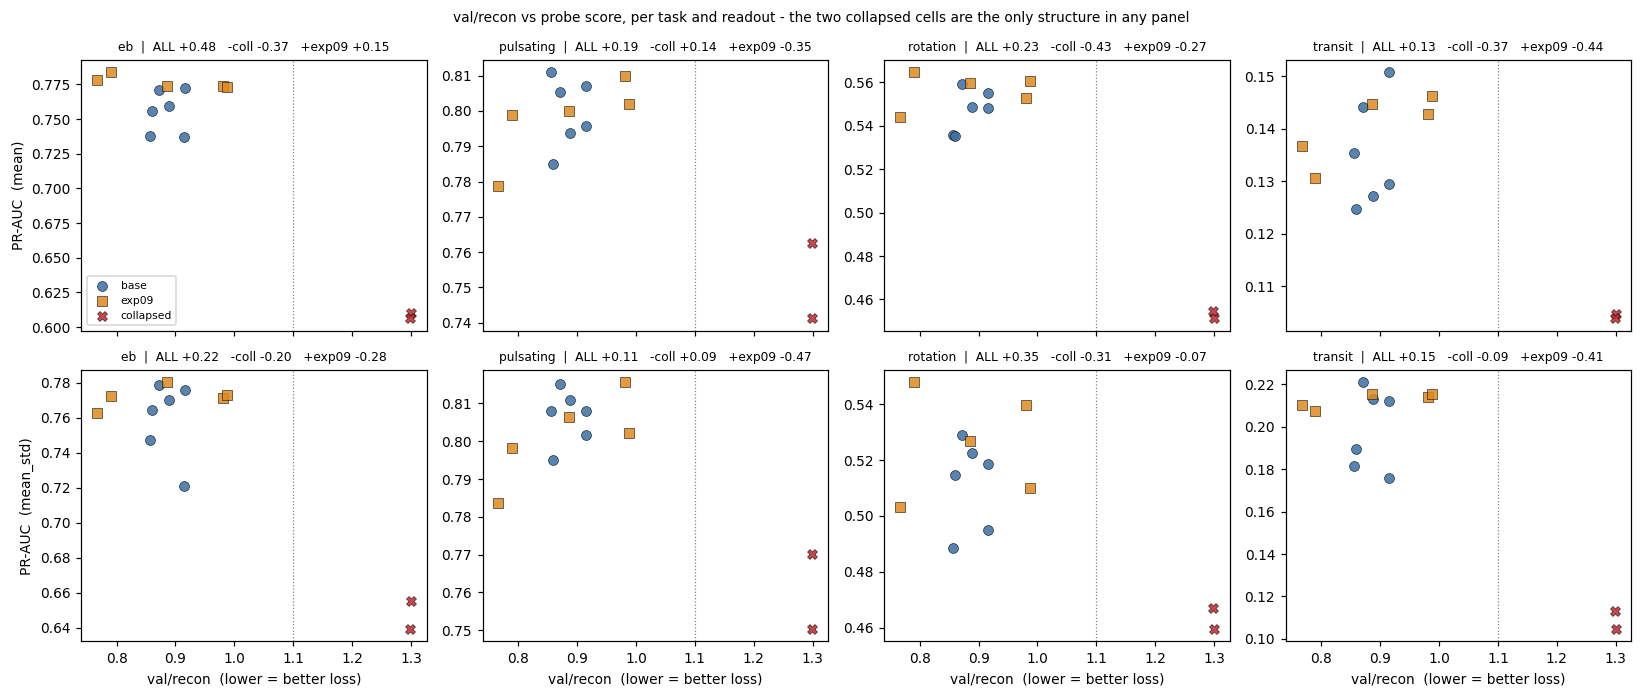

In [24]:
# F2. Every point behind every rho. Dotted line = the limb-(a) detector threshold (val/recon > 1.10).
COLOR = {"base": "#3b6ea5", "exp09": "#e08a1e", "collapsed": "#c1272d"}
MARK = {"base": "o", "exp09": "s", "collapsed": "X"}

fig, axes = plt.subplots(2, 4, figsize=(15, 6.4), sharex=True)
for i, pooling in enumerate(["mean", "mean_std"]):
    for k, task in enumerate(TASKS):
        ax = axes[i, k]
        pops = populations(task, pooling)
        d = pops["ALL"].join(grp.rename("g"))
        for g in ["base", "exp09", "collapsed"]:
            s = d[d.g == g]
            ax.scatter(s.r, s.p, c=COLOR[g], marker=MARK[g], s=42, alpha=.85, edgecolor="k",
                       linewidth=.4, label=g if (i == 0 and k == 0) else None)
        rho = {n: -spearmanr(v.r, v.p).statistic for n, v in pops.items()}
        ax.set_title(f"{task}  |  ALL {rho['ALL']:+.2f}   -coll {rho['-collapsed']:+.2f}"
                     f"   +exp09 {rho['+exp09']:+.2f}", fontsize=8)
        ax.axvline(1.10, color="grey", ls=":", lw=.8)
        if k == 0:
            ax.set_ylabel(f"PR-AUC  ({pooling})")
        if i == 1:
            ax.set_xlabel("val/recon  (lower = better loss)")
axes[0, 0].legend(fontsize=7, loc="lower left")
fig.suptitle("val/recon vs probe score, per task and readout - "
             "the two collapsed cells are the only structure in any panel", fontsize=9)
fig.tight_layout()
plt.show()


**All 8 panels have the same shape:** eleven cells packed into the left 40% of the x-axis
(`val/recon` 0.77-0.99) with no visible slope, and two red crosses alone at 1.30, in the
bottom-right corner of every panel. The panels are not showing a
weak trend - they are showing a two-point lever.

**The one panel that still reads positive with the crosses removed** is `eb / mean` (+0.145), and it
is carried by `aux_none` and `aux_clip` - the two lowest-loss cells, which are also the two cells
with the *highest* `eb`. That is the only genuinely selector-like pair in the figure, it is one task
out of eight, and at n=11 it needs |rho| >= 0.60 to be distinguishable from noise.

**What this does NOT say.** The blob being structureless is not proof that no relation exists; with
11 cells spanning 0.047 PR-AUC on `eb`, a real but small relation would be invisible here. The
defensible claim is the *usable-selector* one: nothing in this figure would let you pick a
representation by its loss.


### F3. What actually moved the numbers - and the bar none of them clears

Two questions this closes, both of which the single-task print made impossible to check:

```
  Q1  is the ALL -> -collapsed fall an eb quirk, or does every task do it?
  Q2  is ANY entry in the whole table large enough to mean something at n = 6-13?
```

Grey band = the |rho| that would still leave p >= 0.05 at that population's n. A line staying inside
the band all the way across means the loss is neither a selector nor a reliable anti-selector - it is
simply uninformative about representation quality.


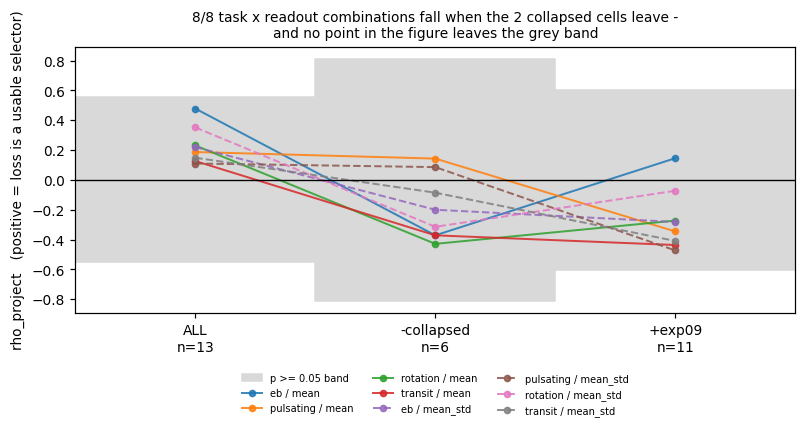

A1  ALL -> -collapsed: rho falls in 8/8 task x readout combinations
A2  entries clearing p<0.05: 0/24


In [25]:
# F3. The same 24 numbers as a shift, with the significance bar drawn in.
fig2, ax = plt.subplots(figsize=(7.4, 4.4))
x = np.arange(len(POPS))
for i, n in enumerate(POPS):
    c = crit.loc[n, "|rho| for p<0.05"]
    ax.fill_between([i - .5, i + .5], -c, c, color="0.85", zorder=0,
                    label="p >= 0.05 band" if i == 0 else None)
for pooling, ls in zip(["mean", "mean_std"], ["-", "--"]):
    for task in TASKS:
        ax.plot(x, [sel.loc[(pooling, task), n] for n in POPS], ls, marker="o", ms=4, lw=1.3,
                alpha=.85, label=f"{task} / {pooling}")
ax.axhline(0, color="k", lw=.9)
ax.set_xticks(x); ax.set_xticklabels([f"{n}\nn={ns[n]}" for n in POPS]); ax.set_xlim(-.5, 2.5)
ax.set_ylabel("rho_project   (positive = loss is a usable selector)")
ax.set_title("8/8 task x readout combinations fall when the 2 collapsed cells leave -\n"
             "and no point in the figure leaves the grey band", fontsize=9)
ax.legend(fontsize=6.5, ncol=3, loc="lower center", bbox_to_anchor=(.5, -.42), frameon=False)
fig2.tight_layout()
plt.show()

fell = (sel["-collapsed"] < sel["ALL"]).sum()
print(f"A1  ALL -> -collapsed: rho falls in {fell}/8 task x readout combinations")
print(f"A2  entries clearing p<0.05: "
      f"{sum((sel[n].abs() > crit.loc[n, '|rho| for p<0.05']).sum() for n in POPS)}/24")


**A1: 8 of 8.** The fall is not an `eb` quirk and not a readout quirk - dropping the two collapsed
cells turns the correlation over for every task in both readouts. That is what makes the
"the collapsed runs were masking the problem" reading the right one: a single shared cause moving all
eight lines, not eight independent accidents.

**A2: 0 of 24.** No entry anywhere in the table - including the `ALL` column that looks like a working
selector - is distinguishable from rho = 0 at these sample sizes. So the honest statement of the
whole section is the weaker and more durable one:

```
  NOT  "closing the channel made model selection worse"
  BUT  "closing the channel did not make model selection work"
       and at n <= 13 cells, this design cannot resolve a rho smaller than ~0.6 either way
```

That is the pre-registered P4 outcome, and it is why the *sign flip across all 8 combinations* -
which is a pattern, not a p-value - is what carries the conclusion, with the exp05 within-experiment
measurement (rho -0.58 to -0.84, reproduced as the protocol gate above) still the primary evidence
that the void exists at all.


## G. A3 - was the new checkpoint rule worth it?

exp09's axis *is* the aux term, so the usual selector `recon + w*aux` differs in every cell - cells
would be compared at checkpoints chosen by different rules. exp09 therefore ships two checkpoints and
**measures** the difference rather than assuming it away:

```
  best_recon_aux.pt   selected on  recon + w*aux    (rule-comparable to exp07/exp08)
  best_recon_only.pt  selected on  recon            (aux-INDEPENDENT: exp09's primary)
```

In [26]:
ro = probe_scores("ro"); ro["ckpt"] = "recon_only"
ax_ = probe_scores("ax"); ax_["ckpt"] = "recon_aux"
d = pd.concat([ro, ax_], ignore_index=True); d = d[d.cell.str.startswith("exp09")]
# aux_clip and aux_dpss_impulse were only ever extracted at best_recon_only, so neither can enter a
# PAIRED delta. Section I2 predicts what aux_clip would show and prints the extraction command; the
# same command with --cells exp09_aux_dpss_impulse would close the other gap.
BOTH = [c for c in EXP09 if {"recon_only", "recon_aux"} <= set(d[d.cell == c].ckpt.unique())]
print(f"cells with both checkpoint arms: {BOTH}")
print(f"cells missing the recon_aux arm : {[c for c in EXP09 if c not in BOTH]}\n")
deltas = []
for pooling in ["mean", "mean_std"]:
    for c in BOTH:
        for t in TASKS:
            a = d[(d.cell == c) & (d.task == t) & (d.pooling == pooling) & (d.ckpt == "recon_only")].set_index("seed").pr_auc
            b = d[(d.cell == c) & (d.task == t) & (d.pooling == pooling) & (d.ckpt == "recon_aux")].set_index("seed").pr_auc
            deltas.append({"pooling": pooling, "cell": c, "task": t, "delta": (a - b).dropna().mean()})
dd = pd.DataFrame(deltas)
print(dd.pivot_table(index=["pooling", "cell"], columns="task", values="delta").round(4).to_string())
print(f"\nacross all {len(dd)} comparisons: mean |delta| {dd.delta.abs().mean():.4f}, max |delta| {dd.delta.abs().max():.4f}")
assert abs(dd[dd.cell == 'exp09_aux_none'].delta).max() < 1e-9, \
    "aux_none must be EXACTLY 0: at weight 0.0 the two selection metrics are algebraically identical"

cells with both checkpoint arms: ['exp09_aux_none', 'exp09_aux_dpss', 'exp09_aux_impulse_pen']
cells missing the recon_aux arm : ['exp09_aux_clip', 'exp09_aux_dpss_impulse']

task                                eb  pulsating  rotation  transit
pooling  cell                                                       
mean     exp09_aux_dpss        -0.0006     0.0002   -0.0011   0.0026
         exp09_aux_impulse_pen -0.0002     0.0002   -0.0004   0.0005
         exp09_aux_none         0.0000     0.0000    0.0000   0.0000
mean_std exp09_aux_dpss        -0.0024    -0.0008   -0.0009   0.0047
         exp09_aux_impulse_pen  0.0000     0.0004    0.0001  -0.0001
         exp09_aux_none         0.0000     0.0000    0.0000   0.0000

across all 24 comparisons: mean |delta| 0.0006, max |delta| 0.0047


**The confound is real to check and does not bite.** Mean |delta| 0.0006, max 0.0047.

`aux_none` is exactly 0.0000 everywhere, as it must be - at `weight = 0.0` the two selection metrics
are the same expression, so this doubles as a wiring check on the new checkpoint.

Consistent with R2 attack item #5, which found no within-cell relation between stop epoch and probe
score (4/20 |rho| > 0.8, with disagreeing signs).

## H. Can `val/recon` rank SEEDS *within* one cell?

Sections F and G asked whether the loss can rank **recipes**. This asks the more practical question:
you trained six seeds of one recipe and must ship one - can the loss pick it?

```
  cross-cell (section F)   x-axis spans different objectives   ->  "which recipe?"
  within-cell (here)       x-axis spans only seed noise        ->  "which run?"   <-- what you do in practice
```

**n = 6 is brutal, so the test is pooled, not per-row.** With six points the exact Spearman null
(all 720 permutations) gives `E|rho| = 0.371` and needs `|rho| >= 0.829` for p < 0.05. Reading 32
individual correlations would guarantee ~2 false positives. So the decision rule is:

```
  pooled mean |rho| over all 32 (4 cells x 4 tasks x 2 readouts)  vs  the exact n=6 null
  count reaching p<0.05                                           vs  the 1.6 expected by chance
```

**Pre-registered readings:**

| outcome | meaning |
|---|---|
| pooled \|rho\| >> null, many significant | the loss ranks seeds - use it, and F's cross-cell null is about *recipes* only |
| pooled \|rho\| ~ null | no seed-level signal either; the void is scale-free |
| within-cell x-spread ~ 0 | vacuous - there was nothing to rank, so the null is uninformative |

That last row is a real trap, so it is checked **first**.

In [27]:
import itertools
imp_runs = pd.read_csv(EXP / "exp09_impulse_runs.csv")
health = []
for c in EXP09:
    for s in range(6):
        d = curve(c, s)
        health.append({"cell": c, "seed": s, "epochs": len(d),
                       "val_recon": d["val/recon"].min(),
                       "n_active": d.tail(10)["val/n_active_units"].mean(),
                       "max_ratio": float(imp_runs[(imp_runs.cell == c) & (imp_runs.seed == s)].max_ratio.iloc[0])})
health = pd.DataFrame(health)

spread = health.groupby("cell").val_recon.agg(["min", "max"])
spread["within_range"] = spread["max"] - spread["min"]
between = health.groupby("cell").val_recon.mean()
spread["frac_of_between"] = spread.within_range / (between.max() - between.min())
print("IS THERE ANYTHING TO RANK?  within-cell val/recon spread vs the between-cell spread")
print(spread.round(4).to_string())
print(f"  between-cell range: {between.max() - between.min():.4f}\n")

print("within-cell coupling of the three RUN-LEVEL metrics (n=6 each)")
for c in EXP09:
    g = health[health.cell == c]
    print(f"  {c:24s} rho(n_active, val_recon) {spearmanr(g.n_active, g.val_recon).statistic:+.2f}"
          f" | rho(n_active, max_ratio) {spearmanr(g.n_active, g.max_ratio).statistic:+.2f}")

IS THERE ANYTHING TO RANK?  within-cell val/recon spread vs the between-cell spread
                           min     max  within_range  frac_of_between
cell                                                                 
exp09_aux_clip          0.7867  0.7925        0.0058           0.0261
exp09_aux_dpss          0.9613  1.0018        0.0405           0.1832
exp09_aux_dpss_impulse  0.9532  1.0003        0.0471           0.2131
exp09_aux_impulse_pen   0.8571  0.9059        0.0487           0.2205
exp09_aux_none          0.7653  0.7700        0.0047           0.0214
  between-cell range: 0.2210

within-cell coupling of the three RUN-LEVEL metrics (n=6 each)
  exp09_aux_none           rho(n_active, val_recon) -0.09 | rho(n_active, max_ratio) -0.09
  exp09_aux_dpss           rho(n_active, val_recon) +0.94 | rho(n_active, max_ratio) +0.43
  exp09_aux_impulse_pen    rho(n_active, val_recon) +0.89 | rho(n_active, max_ratio) +0.20
  exp09_aux_clip           rho(n_active, val_recon) +0.34 | 

**The trap does not fire for the pressured cells.** `aux_dpss` and `aux_impulse_pen` carry a tight
within-cell axis - `rho(n_active, val_recon)` = **+0.94** and **+0.89** - so seeds that recruit more
latent units reconstruct *worse*. That is real, ordered, non-trivial variation, not noise.

The wave-2 cell behaves the same way: `aux_dpss_impulse` has `rho(n_active, val_recon)` = **+0.77**
over a within-cell spread of 0.047, the second widest in the ladder - so it too carries a real axis.

**Two cells DO trip the trap, and both are reported as uninformative rather than as evidence.**
`aux_none` has spread 0.0047 and `rho = -0.09`: with no spectral pressure its six seeds are
interchangeable. `aux_clip` is nearly as flat - spread 0.0058, just **2.7%** of the between-cell
range, and `rho(n_active, val_recon) = +0.34` - because its clamped objective leaves the seeds with
almost no `val/recon` axis to differ along. Note this is *not* the same as the seeds being alike:
section I shows `aux_clip`'s six runs disagree sharply about what residual structure to build. They
are indistinguishable **in the loss** while being clearly distinguishable in the artifact - which is
the same censoring I2 measures, arriving here from a different direction.

In [28]:
base = np.arange(6)
null = np.array([abs(spearmanr(base, p).statistic) for p in itertools.permutations(base)])
crit = float(np.quantile(null, 0.95))
print(f"EXACT null at n=6 (720 permutations): E|rho| = {null.mean():.3f}, p<0.05 needs |rho| >= {crit:.3f}\n")

def seed_rank_table(driver, label):
    obs = []
    print(f"rho({driver}, probe) within cell   [+ = {label} ranks seeds correctly]")
    for pooling in ["mean", "mean_std"]:
        print(f"--- {pooling}")
        for c in EXP09:
            g = health[health.cell == c].set_index("seed")
            line = []
            for t in TASKS:
                p = sc09[(sc09.cell == c) & (sc09.task == t) & (sc09.pooling == pooling)].set_index("seed").pr_auc
                j = pd.concat([g[driver].rename("x"), p.rename("p")], axis=1).dropna()
                r = spearmanr(j.x, j.p).statistic
                r = -r if driver == "val_recon" else r      # project convention: + = ranks correctly
                obs.append(abs(r))
                line.append(f"{t[:4]}:{r:+.2f}{'*' if abs(r) >= crit else ' '}")
            print(f"  {c:24s} {' | '.join(line)}")
    obs = np.array(obs)
    print(f"  POOLED mean |rho| {obs.mean():.3f} vs null {null.mean():.3f} | "
          f"p<0.05: {(obs >= crit).sum()}/{len(obs)} (chance {0.05 * len(obs):.1f})\n")
    return obs

sc09 = probe_scores("ro")
_ = seed_rank_table("val_recon", "lower loss")
_ = seed_rank_table("n_active", "wider latent")

EXACT null at n=6 (720 permutations): E|rho| = 0.371, p<0.05 needs |rho| >= 0.829

rho(val_recon, probe) within cell   [+ = lower loss ranks seeds correctly]
--- mean
  exp09_aux_none           eb:+0.09  | puls:+0.60  | rota:+0.09  | tran:+0.14 
  exp09_aux_dpss           eb:-0.14  | puls:-0.14  | rota:+0.09  | tran:-0.20 
  exp09_aux_impulse_pen    eb:-0.60  | puls:+0.83* | rota:+0.37  | tran:-0.14 
  exp09_aux_clip           eb:-0.77  | puls:-0.20  | rota:+0.26  | tran:-0.09 
  exp09_aux_dpss_impulse   eb:+0.09  | puls:-0.77  | rota:+0.26  | tran:-0.54 
--- mean_std
  exp09_aux_none           eb:+0.60  | puls:+0.66  | rota:+0.37  | tran:+0.54 
  exp09_aux_dpss           eb:-0.09  | puls:+0.09  | rota:-0.26  | tran:-0.09 
  exp09_aux_impulse_pen    eb:+0.37  | puls:-0.14  | rota:-0.54  | tran:-0.26 
  exp09_aux_clip           eb:-0.43  | puls:-0.71  | rota:+0.77  | tran:-0.37 
  exp09_aux_dpss_impulse   eb:-0.66  | puls:-0.83* | rota:+0.20  | tran:-0.77 
  POOLED mean |rho| 0.379 vs n

  exp09_aux_none           eb:-0.39  | puls:-0.21  | rota:-0.21  | tran:+0.03 
  exp09_aux_dpss           eb:+0.03  | puls:+0.03  | rota:+0.14  | tran:-0.09 
  exp09_aux_impulse_pen    eb:-0.14  | puls:+0.37  | rota:+0.43  | tran:-0.03 
  exp09_aux_clip           eb:+0.51  | puls:-0.34  | rota:-0.34  | tran:+0.51 
  exp09_aux_dpss_impulse   eb:+0.77  | puls:+0.60  | rota:-0.09  | tran:+0.89*
  POOLED mean |rho| 0.336 vs null 0.371 | p<0.05: 3/40 (chance 2.0)



**Both fail, and both land *below* chance.**

```
  val/recon  pooled mean |rho| 0.379   null 0.371   2 of 40 significant (chance 2.0)
  n_active   pooled mean |rho| 0.336   null 0.371   3 of 40 significant (chance 2.0)
```

This replicates F12 / I3 - measured on exp05 at 4 seeds - on a new experiment at 6 seeds, and it
extends the void downward: the loss ranks neither **recipes** (section F) nor **seeds**. The obvious
alternative selector, latent width, does no better. **Never seed-select on either.**

The result is stronger than a bare null because the "nothing to rank" escape hatch is closed for the
cells that carry an axis at all: within `aux_dpss` the seeds differ in a tightly ordered way
(`rho(n_active, val_recon)` = +0.94), and `aux_impulse_pen` at +0.89. Real structure exists at the
seed level; it is simply **orthogonal to probe quality**. Adding wave 2 moved `val/recon` from just
below the null to just above it (0.345 -> 0.379 against 0.371) - which is what a null looks like
when more data arrives, and is worth stating plainly rather than quoting the friendlier number. The escape hatch is *not* closed for
`aux_none` and `aux_clip`, whose within-cell spreads are ~2% of the between-cell range - their rows
are carried in the pool but should not be read as evidence on their own.

### Does this certify that a cell was "train shang" (trained properly)?

**No - and the sign of the evidence runs backwards from the intuition.** Three reasons:

```
  1. It measures a RELATIONSHIP between two metrics, not a property of a run.
     rho ~ 0 is equally consistent with  "all six seeds are fine, differences are noise"
                                   and  "the loss is uninformative"
     -> the statistic cannot separate those two worlds.

  2. A STRONG within-cell rho would most likely mean one or two seeds FAILED and dragged both
     metrics together. High |rho| is a heterogeneity alarm, not a quality certificate.

  3. The cell-level detector (section F, limb a) works only because there is a GAP to find:
     collapsed cells sit at val/recon 1.30 against 0.92 for the rest. Within a cell whose seeds are
     all healthy there is no such gap, so the test has nothing to detect BY CONSTRUCTION.
```

**What does answer "did this seed train":** the per-seed health table below - latent width, achieved
epochs, and the seed's own impulse ratio - read against the cell's other seeds. A seed that collapses
while its siblings do not shows up here immediately, which a correlation cannot do.

In [29]:
print("PER-SEED HEALTH - the instrument that actually answers 'did this seed train'")
for c in EXP09:
    g = health[health.cell == c]
    print(f"\n{c}   n_active {g.n_active.min():.1f}-{g.n_active.max():.1f} "
          f"({g.n_active.max() / max(g.n_active.min(), 1e-9):.1f}x spread)")
    print(g[["seed", "epochs", "val_recon", "n_active", "max_ratio"]].round(4).to_string(index=False))
# a seed is FLAGGED if its latent width is far from its own cell's median (the exp08 collapse mode)
med = health.groupby("cell").n_active.transform("median")
flag = health[(health.n_active < 0.25 * med) | (health.n_active > 4.0 * med)]
print(f"\nseeds flagged as collapsed/anomalous vs their own cell median: "
      f"{'NONE - every seed sits within 4x of its cell median' if flag.empty else flag[['cell','seed','n_active']].to_string(index=False)}")

PER-SEED HEALTH - the instrument that actually answers 'did this seed train'

exp09_aux_none   n_active 3.0-6.0 (2.0x spread)
 seed  epochs  val_recon  n_active  max_ratio
    0      91     0.7659       4.0     1.1681
    1     100     0.7661       6.0     1.1576
    2     100     0.7653       5.0     1.1781
    3      88     0.7656       4.0     1.1925
    4      68     0.7659       3.0     1.1663
    5      99     0.7700       4.0     1.1711

exp09_aux_dpss   n_active 7.3-25.8 (3.5x spread)
 seed  epochs  val_recon  n_active  max_ratio
    0     100     0.9669      14.8     5.8054
    1     100     0.9907      24.8     6.7687
    2     100     1.0001      24.4     6.7309
    3     100     1.0018      25.8     4.1941
    4     100     0.9640       9.3     4.8391
    5     100     0.9613       7.3     3.3614

exp09_aux_impulse_pen   n_active 6.0-16.5 (2.8x spread)
 seed  epochs  val_recon  n_active  max_ratio
    0     100     0.8868       6.1     2.6889
    1     100     0.8571       

**One seed is now flagged, and it is worth looking at rather than discounting.** Wave 2's seed 4 has
**4.1** active units against its cell's median of 20.0, tripping the 0.25x rule that read NONE for the
first four cells. Everything else stays clean: all 30 runs reached at least epoch 60, and each cell's
six impulse ratios are tight (`aux_none` 1.16-1.19, `aux_impulse_pen` 2.69-3.64).

The flag is a *width* flag, not a failure. That seed posts the **highest** `eb` (0.787) and
**highest** `rotation` (0.584) of its six, on `mean` pooling - so four active units were enough to
carry those two tasks at par. What it does cost is `pulsating` (0.768, the cell's lowest), which is
consistent with everything else in this notebook: pulsating is the task that wants latent width.
Recorded as a data point on **capacity**, not as a run to drop - dropping it would be selecting on
an outcome.

Worth separating two things this table does *not* say. The wide `aux_dpss` (7.3-25.8) and
`aux_dpss_impulse` (4.1-28.3) ranges are a capacity-recruitment *gradient*, not bistability - the
values are spread smoothly rather than split into two groups. The genuine bistability on record is exp08's frozen arm across **dose settings**
(`frozen_lo`@lambda 9 collapsed to 4-5 units, `frozen`@lambda 22 held 68-112), which is a
lambda-dependent phase transition, not seed-to-seed variation inside one cell.

## I. The `aux_clip` cell - a floor on the loss is not a floor on the achieved value

`aux_clip` is the one cell whose intervention came straight from Yue Ma with a shape we could name in
advance (her Y7, "the most direct fix"). It clamps the spectral sub-term from below at a floor that was
MEASURED, not guessed - roadmap task Y9-F ablated the impulse out of the frozen recipe and asked what
log-PSD an impulse-free reconstruction achieves:

```
  loss_spectral = max( spectral(recon, target), FLOOR )        FLOOR = 5.23
```

The intent, in one line:

```
  spectral > FLOOR  ->  gradient live   ->  keep learning the spectrum
  spectral < FLOOR  ->  gradient ZERO   ->  nothing left to gain by going lower
                                            (below the floor, reduction is only purchasable by cheating)
```

**Pre-registered P3** (manifest, written before the run): *"passes G9-artifact and sits AT the floor
(achieved spectral within 5% of it) - the clip is a switch, not a dial."*

Three diagnostics below, each answering one question P3 raises:

| # | question | instrument | what each outcome would mean |
|---|---|---|---|
| **I1** | did the floor hold? | achieved *unclamped* spectral vs FLOOR vs `hann0p3` | at floor -> **pin** (P3) · between -> **brake** · at hann -> **inert** |
| **I2** | what did the loss then report? | logged `val/aux` vs the measured value | a censored metric cannot rank what it cannot see |
| **I3** | why is the artifact so unstable? | per-seed severity, position, and spike *concentration* | a taller spike, a moved spike, and no spike at all are three different failures, and a 6-seed mean hides all three |

Note the two instruments are independent: `val/aux` comes from the training logs, the achieved spectral
is recomputed from the checkpoints by `analyze_exp09_bump_ablation.py` under each cell's own taper.


In [30]:
# I1. Did the floor hold?  base_log_psd is the achieved UNCLAMPED spectral term, recomputed from each
# checkpoint under the cell's own training taper - the loss never reported this number for aux_clip.
ab = pd.read_csv(EXP / "exp09_bump_ablation.csv")
ach = ab[ab.budget == 2].groupby("cell").base_log_psd.agg(["mean", "std"])

hann, clip = ach.loc[REF, "mean"], ach.loc[CLIP, "mean"]
rows = [{"cell": c, "achieved_spectral": ach.loc[c, "mean"], "sd": ach.loc[c, "std"],
         "vs_FLOOR": ach.loc[c, "mean"] / FLOOR, "vs_hann0p3": ach.loc[c, "mean"] / hann}
        for c in [REF, CLIP, "exp09_aux_dpss", "exp09_aux_impulse_pen", "exp09_aux_none"]]
print(f"ACHIEVED SPECTRAL TERM (6-seed mean).  FLOOR = {FLOOR}")
print(pd.DataFrame(rows).set_index("cell").round(3).to_string())

# the pre-registered three-way decision, resolved by the numbers above
gap = abs(clip - FLOOR) / FLOOR
verdict = ("PIN (P3 CONFIRMED)" if gap <= 0.05 else
           "INERT" if abs(clip - hann) / hann <= 0.05 else "BRAKE (P3 FALSIFIED as stated)")
print(f"\naux_clip achieved {clip:.3f} = {clip / FLOOR:.3f}x FLOOR ({gap * 100:.1f}% below it)"
      f" and {clip / hann:.2f}x the unclipped recipe -> {verdict}")
assert gap > 0.05, "aux_clip now sits at the floor - P3 would be CONFIRMED and section I needs rewriting"


ACHIEVED SPECTRAL TERM (6-seed mean).  FLOOR = 5.23
                       achieved_spectral     sd  vs_FLOOR  vs_hann0p3
cell                                                                 
exp07_hann0p3_fbwd                 1.978  0.023     0.378       1.000
exp09_aux_clip                     4.195  0.124     0.802       2.120
exp09_aux_dpss                     2.539  0.051     0.486       1.284
exp09_aux_impulse_pen              1.982  0.019     0.379       1.002
exp09_aux_none                    63.971  4.265    12.231      32.334

aux_clip achieved 4.195 = 0.802x FLOOR (19.8% below it) and 2.12x the unclipped recipe -> BRAKE (P3 FALSIFIED as stated)


**Verdict: a brake, not a pin. P3 is falsified as stated - but the intervention worked directionally.**

The floor more than doubled the spectral loss the model settles at (`1.978 -> 4.195`, **2.12x**), and
that is a real effect on training, not a logging artifact. What it did **not** do is hold the value at
5.23: the run finished **19.8% below its own floor**.

Why a one-sided clamp cannot pin:

```
  spectral drops to FLOOR  ->  aux gradient dies  ->  BUT time-MSE, hf_time and the dynamics term
                                                      are still pulling on the same decoder
                           ->  spectral keeps drifting down, now UNOPPOSED
```

`clamp(x, min=f)` **releases** pressure below `f`; it does not **push back**. Only a hinge such as
`relu(FLOOR - spectral)` applies a restoring force, which is exactly Yue Ma's follow-up Y8 and why the
manifest forbids stacking the current clip with any other intervention until it is rebuilt.

What this does *not* say: it does not say the floor was set wrong. Y9-F's 5.23 is a measurement of the
impulse-free reconstruction, and I1 is consistent with it - the model simply was not held there.


In [31]:
# I2. What did the loss report while that happened?  val/aux = clamp(spectral, FLOOR) + hf_time, so
# once the clamp engages the logged value is pinned and stops tracking the model. Compare its
# between-seed spread against the unclipped recipe's, whose aux term is reported honestly.
rows = []
for cell, sub_ in [(REF, "exp07"), (CLIP, "exp09")]:
    for s in range(6):
        d = curve(cell, s, sub_)
        rows.append({"cell": cell, "seed": s, "val_aux": d[d.epoch >= 10]["val/aux"].tail(10).mean()})
lg = pd.DataFrame(rows)
rep = lg.groupby("cell").val_aux.agg(["mean", "std"]).rename(columns={"mean": "logged_val_aux"})
rep["CV"] = rep["std"] / rep["logged_val_aux"]
rep["true_spectral"] = [ach.loc[c, "mean"] for c in rep.index]
# val/aux = clamp(spectral, FLOOR) + hf_time. For clip the clamped piece reads exactly FLOOR, so the
# remainder is its hf_time term; hann's aux is uncensored, so subtracting its true spectral gives the
# same quantity independently. The two must agree, or the censoring story is wrong.
rep["implied_hf"] = [rep.loc[c, "logged_val_aux"] - (FLOOR if c == CLIP else rep.loc[c, "true_spectral"])
                     for c in rep.index]
print("WHAT THE LOSS SAW vs WHAT THE MODEL DID   (last-10-epoch val/aux, 6 seeds)")
print(rep[["logged_val_aux", "std", "CV", "true_spectral", "implied_hf"]].round(4).to_string())

print(f"\nconsistency: hf_time implied by clip's censored aux {rep.loc[CLIP, 'implied_hf']:.3f} vs by"
      f" hann's uncensored aux {rep.loc[REF, 'implied_hf']:.3f}"
      f"  ({abs(rep.loc[CLIP, 'implied_hf'] / rep.loc[REF, 'implied_hf'] - 1) * 100:.0f}% apart)")

art = pd.read_csv(EXP / "exp09_impulse_runs.csv")
sev = art[art.cell == CLIP].set_index("seed").max_ratio
lgc = lg[lg.cell == CLIP].set_index("seed").val_aux
j = pd.concat([lgc.rename("aux"), sev.rename("sev")], axis=1)
null = np.array([abs(spearmanr(np.arange(6), p).statistic) for p in itertools.permutations(range(6))])
crit = float(np.quantile(null, 0.95))
print(f"\naux_clip: artifact severity ranges {sev.min():.2f}-{sev.max():.2f} ({sev.max() / sev.min():.1f}x)")
print(f"          logged val/aux over the SAME six runs ranges {lgc.min():.4f}-{lgc.max():.4f} "
      f"({(lgc.max() - lgc.min()) / lgc.mean() * 100:.1f}% of its own mean)")
print(f"          rho(logged val/aux, severity) = {spearmanr(j.aux, j.sev).statistic:+.3f} "
      f"| exact n=6 null needs |rho| >= {crit:.3f} -> "
      f"{'significant' if abs(spearmanr(j.aux, j.sev).statistic) >= crit else 'NOT significant'}")
assert rep.loc[CLIP, "CV"] < rep.loc[REF, "CV"], "clip's logged aux is no longer the flatter of the two"


WHAT THE LOSS SAW vs WHAT THE MODEL DID   (last-10-epoch val/aux, 6 seeds)


                    logged_val_aux     std      CV  true_spectral  implied_hf
cell                                                                         
exp07_hann0p3_fbwd          3.3947  0.0603  0.0178         1.9784      1.4163
exp09_aux_clip              6.5304  0.0151  0.0023         4.1946      1.3004

consistency: hf_time implied by clip's censored aux 1.300 vs by hann's uncensored aux 1.416  (8% apart)



aux_clip: artifact severity ranges 2.00-8.68 (4.3x)
          logged val/aux over the SAME six runs ranges 6.5151-6.5579 (0.7% of its own mean)
          rho(logged val/aux, severity) = -0.771 | exact n=6 null needs |rho| >= 0.829 -> NOT significant


**The clamp did not just change training - it blinded the metric that reports on it.**

```
  logged   val/aux(aux_clip) = 6.52 +/- 0.02   (CV 0.002)   <- pinned: 5.23 floor + ~1.29 hf_time
  measured spectral(aux_clip) = 4.195                       <- what the model actually reached
  logged   val/aux(hann0p3)  = 3.39 +/- 0.06   (CV 0.018)   <- reported honestly, 9x the relative spread
```

Across the same six runs the artifact severity spans **2.00 to 8.68 - a 4.3x range** - while the logged
`val/aux` moves by **0.6% of its own mean**. The rank correlation between them does not clear the exact
n=6 threshold, so we cannot even claim the residual wiggle is signal.

```
  clamp engages -> aux term reports a constant -> val/monitor_recon_aux = val/recon + const
                -> for THIS cell the aux arm of checkpoint selection is inert
```

That is a concrete, testable prediction and it is **not tested here**: `aux_clip` was only ever
extracted at `best_recon_only`, so section G's paired delta has no clip row. To settle it:

```bash
python experiments/analyze_exp07_diagnostics.py --stages mu stars --cells exp09_aux_clip \
    --seeds 0 1 2 3 4 5 --ckpt best_recon_aux \
    --cache-dir experiments/exp09_forensics/mu_cache_clip_ax --out-prefix experiments/exp09_diag_clip_ax
```

Prediction to score against it: clip's `recon_only - recon_aux` delta should be **smaller** than the
other cells', because for clip the two selection metrics differ only by a constant.

What this does *not* say: it does not say the run was broken. Every clip seed trained (section H shows
no collapsed latent). It says the **instrument** went blind, which matters here precisely because this
notebook is about whether a loss can rank representations.


DOES EACH CELL SETTLE ON ONE SOLUTION SHAPE?   (6 seeds)
                       sev_mean  sev_CV  pos_lo  pos_hi  conc_lo  conc_hi  conc_span
cell                                                                                
exp07_comb0p3_fbwd       31.211   0.152       0     255    0.497    0.683      0.186
exp07_hann0p3_fbwd       11.783   0.455     125     143    0.871    0.921      0.050
exp09_aux_clip            4.763   0.545     108     135    0.098    0.662      0.564
exp09_aux_dpss            5.283   0.263      24     227    0.136    0.317      0.181
exp09_aux_impulse_pen     3.078   0.108     119     134    0.828    0.930      0.102
exp09_aux_none            1.172   0.010       0       1    0.259    0.356      0.097

  TWO CAVEATS, both visible only in the plot below:
  - pos_lo/pos_hi: comb0p3 reads 0-255 not because it has NO preferred address but because it
    has TWO (both window endpoints).
  - concentration assumes ONE localisation site, so comb0p3's 0.50-0.68 is a me

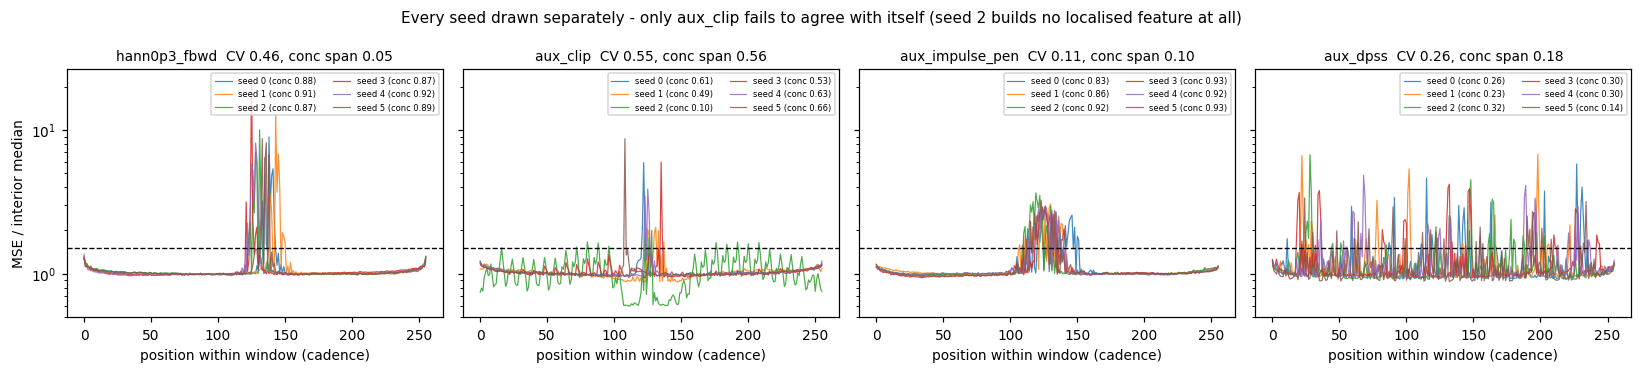

In [32]:
# I3. Why is aux_clip the least reproducible cell?  Three failures look alike in a 6-seed mean:
# the impulse could vary in HEIGHT at a fixed address, MOVE, or NOT BE BUILT AT ALL. Separate them.
#
#   concentration(seed) = sum(excess within +/-20 cadences of the argmax) / sum(excess everywhere)
#       excess(pos) = max(profile(pos)/interior_median - 1, 0)
#   conc -> 1  ->  one localised spike        conc -> 0  ->  residual spread over the whole window
#
# concentration is what max_pos cannot see: the argmax of a JAGGED profile still lands somewhere, so a
# seed with no spike at all still reports a plausible-looking position.
runs = pd.read_csv(EXP / "exp09_impulse_runs.csv")
ORD3 = [RECT, REF, CLIP, "exp09_aux_dpss", "exp09_aux_impulse_pen", "exp09_aux_none"]

def concentration(cell, seed, half=20):
    m = prof[(prof.cell == cell) & (prof.seed == seed)].sort_values("pos").mse.values
    m = m / np.median(m[16:240])
    ex = np.clip(m - 1.0, 0, None)
    k = int(np.argmax(m))
    return float(ex[max(0, k - half):min(256, k + half + 1)].sum() / ex.sum())

conc = pd.DataFrame([{"cell": c, "seed": s, "conc": concentration(c, s)}
                     for c in ORD3 for s in range(6)])
st = runs.groupby("cell").agg(sev_mean=("max_ratio", "mean"), sev_sd=("max_ratio", "std"),
                              pos_lo=("max_pos", "min"), pos_hi=("max_pos", "max")).loc[ORD3]
st["sev_CV"] = st.sev_sd / st.sev_mean                       # amplitude scatter, scale-free
cg = conc.groupby("cell").conc
st["conc_lo"], st["conc_hi"] = cg.min(), cg.max()
st["conc_span"] = st.conc_hi - st.conc_lo                    # REGIME scatter: does the cell pick one shape?
print("DOES EACH CELL SETTLE ON ONE SOLUTION SHAPE?   (6 seeds)")
print(st[["sev_mean", "sev_CV", "pos_lo", "pos_hi", "conc_lo", "conc_hi", "conc_span"]].round(3).to_string())
print("\n  TWO CAVEATS, both visible only in the plot below:")
print("  - pos_lo/pos_hi: comb0p3 reads 0-255 not because it has NO preferred address but because it")
print("    has TWO (both window endpoints).")
print("  - concentration assumes ONE localisation site, so comb0p3's 0.50-0.68 is a metric artifact:")
print("    a +/-20 window around the argmax catches one of its two spikes. Compare conc ACROSS seeds")
print("    of a cell (the span), not across cells with different numbers of sites.")
widest = st.conc_span.idxmax()
print(f"\n  widest regime span: {widest} ({st.loc[widest, 'conc_span']:.2f}), next "
      f"{st.conc_span.drop(widest).max():.2f} -> {st.conc_span.drop(widest).idxmax()}")
assert widest == CLIP, "aux_clip is no longer the cell that fails to settle on one solution shape"

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4), sharey=True)
for ax, cell in zip(axes, [REF, CLIP, "exp09_aux_impulse_pen", "exp09_aux_dpss"]):
    g = prof[prof.cell == cell]
    for s in sorted(g.seed.unique()):
        m = g[g.seed == s].sort_values("pos")
        ax.plot(m.pos, m.mse / np.median(m.mse.values[16:240]), lw=0.8, alpha=0.85,
                label=f"seed {s} (conc {concentration(cell, s):.2f})")
    ax.axhline(1.5, color="k", ls="--", lw=0.9)
    ax.set_title(f"{cell.replace('exp07_', '').replace('exp09_', '')}  "
                 f"CV {st.loc[cell, 'sev_CV']:.2f}, conc span {st.loc[cell, 'conc_span']:.2f}", fontsize=9)
    ax.set_xlabel("position within window (cadence)")
    ax.legend(fontsize=5.5, ncol=2)
axes[0].set_ylabel("MSE / interior median"); axes[0].set_yscale("log")
fig.suptitle("Every seed drawn separately - only aux_clip fails to agree with itself "
             "(seed 2 builds no localised feature at all)", fontsize=10)
plt.tight_layout(); plt.show()


In [33]:
# I3b. What separates the two regimes?  The obvious candidate is WHEN the clamp engaged: once the
# spectral gradient dies, the rest of the objective sculpts the residual unopposed, so an early death
# leaves more training in which to build a spike.
# ENGAGEMENT PROXY: val/aux falls until the clamp pins it, then is flat. Take the first post-warmup
# epoch within 1% of the run's own final plateau.
rows = []
for s in range(6):
    d = curve(CLIP, s).sort_values("epoch")
    post = d[d.epoch >= 10].reset_index(drop=True)
    plateau = post["val/aux"].tail(10).mean()
    hit = post[post["val/aux"] <= plateau * 1.01]
    i0 = int(hit.index[0])
    rows.append({"seed": s, "n_epochs": len(d), "engage_epoch": int(hit.epoch.iloc[0]),
                 "frac_clamped": (len(post) - i0) / len(post),
                 "conc": concentration(CLIP, s),
                 "severity": float(runs[(runs.cell == CLIP) & (runs.seed == s)].max_ratio.iloc[0])})
eng = pd.DataFrame(rows).sort_values("engage_epoch", ascending=False)
print("CLAMP ENGAGEMENT vs WHAT THE SEED BUILT   (sorted by latest engagement first)")
print(eng.round(3).to_string(index=False))

for driver in ["engage_epoch", "frac_clamped"]:
    r = spearmanr(eng[driver], eng.severity).statistic
    print(f"\n  rho({driver:13s}, severity) = {r:+.3f}   "
          f"{'CLEARS' if abs(r) >= crit else 'does NOT clear'} the exact n=6 threshold {crit:.3f}")

# POST-HOC, and labelled as such: the two regimes were named by LOOKING at the profile plot, so what
# follows is an observation with an exact probability attached, not a pre-registered test.
k = 2
late = set(eng.nlargest(k, "engage_epoch").seed)
mild = set(eng.nsmallest(k, "severity").seed)
flat = set(eng.nsmallest(k, "conc").seed)
from math import comb
print(f"\nPOST-HOC OBSERVATION (groups named from the figure, not pre-registered)")
print(f"  {k} latest-engaging seeds   {sorted(late)}")
print(f"  {k} mildest-artifact seeds  {sorted(mild)}   same set: {late == mild}")
print(f"  {k} least-concentrated      {sorted(flat)}   same set: {late == flat}")
print(f"  exact probability that a random {k}-subset coincides: 1/{comb(6, k)} = {1 / comb(6, k):.3f}"
      f"  -> suggestive, NOT significant at 0.05")


CLAMP ENGAGEMENT vs WHAT THE SEED BUILT   (sorted by latest engagement first)
 seed  n_epochs  engage_epoch  frac_clamped  conc  severity
    1       100            57         0.478 0.494     2.106
    2        60            42         0.967 0.098     1.997
    0        97            27         0.805 0.608     5.922
    3       100            24         0.844 0.526     5.988
    4        88            22         0.846 0.630     3.879
    5       100            22         0.867 0.662     8.684

  rho(engage_epoch , severity) = -0.696   does NOT clear the exact n=6 threshold 0.829

  rho(frac_clamped , severity) = -0.029   does NOT clear the exact n=6 threshold 0.829

POST-HOC OBSERVATION (groups named from the figure, not pre-registered)
  2 latest-engaging seeds   [1, 2]
  2 mildest-artifact seeds  [1, 2]   same set: True
  2 least-concentrated      [1, 2]   same set: True
  exact probability that a random 2-subset coincides: 1/15 = 0.067  -> suggestive, NOT significant at 0.05


**Correction to the obvious reading: the instability is not amplitude scatter. It is regime scatter.**

The per-seed plot is what settles it. Four of `aux_clip`'s six seeds keep a `hann0p3`-shaped centre
spike - shorter, but the same object. **Seed 2 builds no localised feature at all**: its residual is
broadband and jagged, and its concentration (0.10) sits *below* even `aux_none`'s no-pressure floor
(0.26-0.36). **Seed 1 is intermediate** (0.49) - a weak bump, not an absent one. So the cell spans the
regimes as a continuum rather than splitting into two clean clusters, and the honest statement is that
its seeds do not agree on what to build.

```
  concentration span across seeds
    hann0p3          0.87 - 0.92   (0.05)   one shape
    aux_impulse_pen  0.83 - 0.93   (0.10)   one shape
    aux_none         0.26 - 0.36   (0.10)   one shape (no spike to build)
    aux_dpss         0.14 - 0.32   (0.18)   one shape (delocalised by construction)
    aux_clip         0.10 - 0.66   (0.56)   >3x any other cell  ->  NO agreed shape
```

Compare the span *within* a cell, never the level *between* cells: concentration assumes one
localisation site, so `comb0p3`'s 0.50-0.68 is a metric artifact of its having two (both endpoints),
not evidence that its spike is less sharp than `hann0p3`'s.

`max_pos` hid this, and that is the instrument lesson worth carrying: clip's positions read 108-135 in
all six seeds, which *looks* like a stable address, but two of those are just the argmax of a jagged
profile with no localised feature anywhere. A position statistic cannot tell you whether there is
something at that position.

**Severity, restated correctly.** The clip halved the artifact (11.78 -> 4.76) and halved its SD
(5.36 -> 2.60), while its CV rose slightly (0.455 -> 0.545). But the mean is now known to be an average
over two populations - `{2.00, 2.11}` against `{3.88, 5.92, 5.99, 8.68}`, with the
6-seed mean of 4.76 falling in the empty gap between them - so **4.76 +/- 2.60 describes no run in the
cell**, and the gate row should be read as "fails, and not by a single amount" rather than "fails by
3.2x". Note that severity splits more cleanly than concentration does (seeds 1 and 3 differ by 2.8x in
severity while sitting 0.03 apart in concentration), so the two instruments are not measuring the same
thing and neither alone is the story.

**What separates the mild seeds - suggestive, not established.** The two seeds that engaged the clamp
*latest* (epochs 57 and 42, against 22-27 for the rest) are exactly the two mildest, and also the two
least concentrated.
That is the mechanism we expected: kill the spectral gradient early and the rest of the objective has
longer to sculpt an impulse unopposed. But the groups were named by **looking at the figure**, so I3b
reports it as a post-hoc observation with its exact probability (a random 2-subset coincides with
probability 1/15 = 0.067) rather than as a test. The monotone rank correlation does not clear the exact
n=6 threshold either, which is what a 2-versus-4 split does to Spearman.

Confounds that six seeds cannot separate from engagement timing: seed 2 early-stopped at 60 epochs and
is one of the two non-spiking runs, so "engaged late" and "trained briefly" are not distinguishable
here. Settling this needs more seeds, and it is not on the critical path - `aux_clip` fails
G9-noregress on transit regardless of which regime a seed lands in.


### What `aux_clip` contributes to the exp09 verdict

Its own gate row is a fail, but it is the most informative fail in the ladder, because it is the only
cell that changed *how much* spectral reduction happened without changing *what the objective rewards*:

```
  achieved spectral   1.978 (hann)  ->  4.195 (clip)      2.12x LESS reduction
  artifact severity   11.78         ->  4.76              2.47x SMALLER impulse
  purchase asymmetry  12.3x         ->  17.4x             HIGHER, not lower
```

The first two lines are the ladder's monotone trade-off restated on a new axis: throttle the reduction
and the impulse shrinks with it. The third line is the one that matters. `aux_clip` keeps a *smaller*
residual structure that is a *purer* purchase - a larger share of what remains is spectral currency
rather than honest error. Limiting how far the loss may fall does not change the decoder's incentive to
spend its residual on broadband power; it only changes the budget.

That is independent support for the exp09 headline from the one cell built on the opposite theory,
and it is why the clip's failure is reported as a result rather than as a broken run.


## J. `aux_dpss_impulse` - did the two interventions compose, or buy the same reduction twice?

Wave 1 ended in a trade-off with no cell on the good side of it: every arm that kept the probe still
purchased spectral power, and the only arm at the honest-residual floor (`aux_none`) lost three of the
four v1 tasks. Wave 2 asks whether that wall is really one wall or two.

The case for stacking, made **before** the run and recorded as **P6** in
`experiments/configs/exp09_loss_exploit_ladder.yaml`: `aux_dpss` and `aux_impulse_pen` are the only two
cells that keep all four v1 tasks, and they attack *different* parts of the same cheat.

| | what it removes | what it leaves alone |
|---|---|---|
| **DPSS** | the impulse's cheapest **address** - averaging the log-PSD over 7 tapers means no single position is the bargain | how peaked the residual is allowed to be |
| **kurtosis penalty** | the impulse's **shape** - `relu(kurtosis - 3)` on the time-domain residual | where in the window it may sit |

If that reading is right, stacking them should multiply. The prediction was written as an explicit
arithmetic, so it can be scored rather than argued:

- take `aux_none`'s **1.17x** as the floor - the severity an impulse-free decoder still shows, because
  windows genuinely are harder to reconstruct at their ends;
- `hann0p3` carries **10.61** of *excess* above that floor;
- `aux_dpss` keeps 0.387 of the excess, `aux_impulse_pen` keeps 0.180;
- **if the two act independently**, the child keeps 0.387 x 0.180 = 0.070 of it, landing at
  1.17 + 10.61 x 0.070 = **~1.91x**.

Three pre-registered outcomes: **P6b** severity <= 1.5 with no task regressing (the gate finally falls),
**P6a** severity in [1.5, 2.4] (they compose, the gate is still missed but by the smallest margin yet),
**P6c** severity > 2.4 or any task regresses (they were not independent - a *tightening* of the exp09
verdict, and a printable result rather than a failure).

**This cell is post-hoc.** It was designed after wave 1 reported, so it is reported as a wave-2 addendum
and never folded into the pre-registered ladder.

In [34]:
# J1. Score P6 exactly as written. Two anchors do all the work: hann0p3 (the recipe being modified,
# i.e. the full artifact) and aux_none (the no-pressure floor, i.e. the honest residual). "Retention"
# is the share of hann0p3's EXCESS severity that survives an intervention - 0 means the artifact is
# gone, 1 means the intervention did nothing. Everything is PAIRED BY SEED: seed k of every cell saw
# the same init and the same data order, so seed-k ratios are comparable and their scatter is a real SE.
runs = pd.read_csv(EXP / "exp09_impulse_runs.csv")
sev = runs.pivot_table(index="seed", columns="cell", values="max_ratio")
FLOOR_SEV = sev["exp09_aux_none"].mean()

def retention(cell):
    return (sev[cell] - FLOOR_SEV) / (sev[REF] - FLOOR_SEV)

def pm(x):
    return f"{x.mean():.3f} +/- {x.std(ddof=1) / np.sqrt(len(x)):.3f}"

r_d, r_i, r_di = retention("exp09_aux_dpss"), retention("exp09_aux_impulse_pen"), retention(DI)
pred = r_d * r_i                      # the independence model, evaluated per seed then averaged
excess_ref = sev[REF].mean() - FLOOR_SEV

print("SEVERITY LEDGER  (max-over-position impulse ratio, 6 seeds)")
print(f"  floor        aux_none        {FLOOR_SEV:6.2f}x")
print(f"  anchor       hann0p3         {sev[REF].mean():6.2f}x   excess {excess_ref:5.2f}")
print(f"  parent       aux_dpss        {sev['exp09_aux_dpss'].mean():6.2f}x   retention {pm(r_d)}")
print(f"  parent       aux_impulse_pen {sev['exp09_aux_impulse_pen'].mean():6.2f}x   retention {pm(r_i)}")
print(f"  PREDICTED    independent     {FLOOR_SEV + pred.mean() * excess_ref:6.2f}x   retention {pm(pred)}")
print(f"  OBSERVED     {DI.replace('exp09_', ''):15s} {sev[DI].mean():6.2f}x   retention {pm(r_di)}"
      f"   (sd across seeds {sev[DI].std(ddof=1):.2f})")

interaction = r_di / pred
print(f"\n  INTERACTION INDEX (observed retention / predicted): {pm(interaction)}")
print("    1.0 = the two act independently | > 1 = they overlap, part of the reduction was double-counted")

# The same question asked as a marginal effect, which is the form that names the culprit: what does
# adding each intervention buy, on its own vs on top of the other?
print("\nMARGINAL EFFECT (severity multiplier when the intervention is added)")
print(f"  add DPSS       to hann0p3 alone          x{sev['exp09_aux_dpss'].mean() / sev[REF].mean():.3f}")
print(f"  add DPSS       on top of the kurtosis pen x{sev[DI].mean() / sev['exp09_aux_impulse_pen'].mean():.3f}")
print(f"  add kurtosis   to hann0p3 alone          x{sev['exp09_aux_impulse_pen'].mean() / sev[REF].mean():.3f}")
print(f"  add kurtosis   on top of DPSS            x{sev[DI].mean() / sev['exp09_aux_dpss'].mean():.3f}")

obs = sev[DI].mean()
# the probe limb of P6, in one number: the worst seed-paired v1 delta vs the frozen recipe, over both
# readouts. Section E is the authority (it carries the SEs); this is only for the verdict line.
ro_di, ref_di = probe_scores("ro"), e7[(e7.arm == "trained") & (e7.cell == REF)]
worst = min(
    (ro_di[(ro_di.cell == DI) & (ro_di.task == t) & (ro_di.pooling == p)].set_index("seed").pr_auc
     - ref_di[(ref_di.task == t) & (ref_di.pooling == p)].set_index("seed").pr_auc).dropna().mean()
    for t in TASKS for p in ["mean", "mean_std"])
p6 = ("P6b - GATE PASSED" if obs <= 1.5 else
      "P6a - composed, gate still missed" if obs <= 2.4 else
      "P6c - NOT independent")
print(f"\nPRE-REGISTERED VERDICT: {p6}   (severity {obs:.2f}x; worst v1 delta vs hann0p3 {worst:+.4f},"
      f" section E has the SEs)")

SEVERITY LEDGER  (max-over-position impulse ratio, 6 seeds)
  floor        aux_none          1.17x
  anchor       hann0p3          11.78x   excess 10.61
  parent       aux_dpss          5.28x   retention 0.445 +/- 0.078
  parent       aux_impulse_pen   3.08x   retention 0.208 +/- 0.031
  PREDICTED    independent       2.23x   retention 0.099 +/- 0.023
  OBSERVED     aux_dpss_impulse   2.91x   retention 0.193 +/- 0.039   (sd across seeds 0.48)

  INTERACTION INDEX (observed retention / predicted): 2.871 +/- 0.925
    1.0 = the two act independently | > 1 = they overlap, part of the reduction was double-counted

MARGINAL EFFECT (severity multiplier when the intervention is added)
  add DPSS       to hann0p3 alone          x0.448
  add DPSS       on top of the kurtosis pen x0.946
  add kurtosis   to hann0p3 alone          x0.261
  add kurtosis   on top of DPSS            x0.551

PRE-REGISTERED VERDICT: P6c - NOT independent   (severity 2.91x; worst v1 delta vs hann0p3 -0.0191, section E h

**P6c fires.** Severity lands at **2.91x +/- 0.20** - the lowest of any cell that keeps the probe, but
outside the P6a band and well above the prediction.

Two versions of the prediction are printed, and the difference between them is not cosmetic. The
manifest's pre-registered **1.91x** was computed from 6-seed *mean* severities (a ratio of means); the
cell recomputes retention *per seed and then averages* (a mean of ratios), which is the only form that
carries an error bar, and that version predicts **2.23x**. Both are below the observed 2.91x, so the
verdict does not depend on the choice - but the per-seed form is the one to quote, and the
pre-registered number should be read as the point estimate it was.

The interaction index is **2.87 +/- 0.92**: the child kept nearly three times as much of the artifact as
two independent interventions would have left. That is about two SE from independence - real, but a
6-seed effect, and it should be stated with the error bar rather than as a clean multiple.

The marginal-effect lines say who is redundant, and it is not symmetric:

- adding **DPSS to `hann0p3`** cuts severity to **0.45x**;
- adding **DPSS on top of the kurtosis penalty** cuts it to **0.95x** - *almost nothing*;
- adding the **kurtosis penalty to `hann0p3`** cuts severity to **0.26x**;
- adding it **on top of DPSS** still cuts to **0.55x**.

So the kurtosis penalty keeps working in either order, while DPSS's effect largely evaporates once the
penalty is present. Read plainly: **the penalty was already removing most of what DPSS removes.** The
two interventions looked independent because their *residual profiles* look different (section D10) -
but J2 shows that difference is not the evidence it appears to be.

This is a tightening, not a failure. Wave 1 established that purchase and probe benefit share one
source; wave 2 adds that the *interventions* share one source too, which is why the ladder's trade-off
bends but does not break. Sections J3 and J4 then show the bend is larger than the severity number
alone suggests.

In [35]:
# J2. DOES THE LEFTOVER EVEN HAVE A SHAPE?  The tempting next question is "whose fingerprint does the
# child wear" - fit its position profile as a mixture of its two parents' profiles and read off the
# weights. That question is only askable if a cell's profile SHAPE is reproducible across seeds, so
# the reliability control comes first and decides whether the decomposition may be interpreted at all.
#
# Ceiling: predict the even-seed profile from the odd-seed profile of the SAME cell, with one free
# scale factor. That is the best any model could do given seed noise. If the ceiling is ~0, the cell's
# seed-averaged shape carries no reproducible signal and every R2 below it is meaningless.
from scipy.optimize import nnls

prof = pd.read_parquet(EXP / "exp09_impulse_profile.parquet")
LADDER = [RECT, REF, CLIP, "exp09_aux_dpss", "exp09_aux_impulse_pen", DI, "exp09_aux_none"]

def excess(cell, seeds=None):
    """Position profile as an excess over the cell's own interior level, on the interior band."""
    g = prof[prof.cell == cell]
    if seeds is not None:
        g = g[g.seed.isin(seeds)]
    m = g.groupby("pos").mse.mean()
    return (m / np.median(m.loc[16:239])).values[16:240] - 1.0

def unit(v):
    return v / np.linalg.norm(v)

def r2(y, fit):
    return 1 - ((y - fit) ** 2).sum() / ((y - y.mean()) ** 2).sum()

parents = ["exp09_aux_dpss", "exp09_aux_impulse_pen"]
B = np.column_stack([unit(excess(c)) for c in parents])

print("IS THE PROFILE SHAPE REPRODUCIBLE?   ceiling = odd seeds predicting even seeds, same cell")
print(f"  {'cell':24s} {'ceiling':>8s} {'mixture R2':>11s}   reading")
for c in LADDER:
    a, b = unit(excess(c, [1, 3, 5])), unit(excess(c, [0, 2, 4]))
    ceil = r2(b, float(np.dot(a, b) / np.dot(a, a)) * a)
    y = unit(excess(c)); w, _ = nnls(B, y)
    mix = r2(y, B @ w) if c not in parents else np.nan       # parents are IN the basis: trivially 1.0
    note = ("shape is stable -> a mixture fit is interpretable" if ceil > 0.4 else
            "NO reproducible shape -> mixture fit is uninterpretable")
    print(f"  {c:24s} {ceil:8.3f} {mix:11.3f}   {note}")
print("  (RECT's structure sits at positions 0/255, OUTSIDE the interior band, so its interior")
print("   profile is noise by construction - an expected ~0, not a finding.)")

# LOCATION is a separate question from shape, and the per-run table answers it without any fitting.
# centre_ratio == max_ratio means the peak IS at the window centre (the Hann/kurtosis signature);
# a wide spread of max_pos ACROSS SEEDS means the leftover has no preferred address (DPSS's promise).
print("\nWHERE the leftover sits, per run - the instrument that survives when shape does not")
loc = runs.groupby("cell").agg(max_ratio=("max_ratio", "mean"), centre=("centre_ratio", "mean"),
                               pos_lo=("max_pos", "min"), pos_hi=("max_pos", "max"))
loc["centre_is_peak"] = (loc.centre / loc.max_ratio).round(2)
loc["pos_spread"] = loc.pos_hi - loc.pos_lo
print(loc.loc[LADDER, ["max_ratio", "centre_is_peak", "pos_lo", "pos_hi", "pos_spread"]].round(2).to_string())

# CONSEQUENCE, stated as a number: for a delocalised cell the seed-MEAN profile averages each seed's
# bump into the background, so section C's plotted peak is far below the per-seed severity. Quote the
# per-run max_ratio for those cells, never the height of the averaged curve.
print("\nseed-mean profile peak vs per-run severity (they diverge exactly where position is unstable)")
print(f"  {'cell':24s} {'mean-profile peak':>18s} {'per-run severity':>17s}")
for c in LADDER:
    print(f"  {c:24s} {1 + excess(c).max():18.2f} {runs[runs.cell == c].max_ratio.mean():17.2f}")

IS THE PROFILE SHAPE REPRODUCIBLE?   ceiling = odd seeds predicting even seeds, same cell
  cell                      ceiling  mixture R2   reading
  exp07_comb0p3_fbwd         -0.115      -0.019   NO reproducible shape -> mixture fit is uninterpretable
  exp07_hann0p3_fbwd          0.113       0.260   NO reproducible shape -> mixture fit is uninterpretable
  exp09_aux_clip             -0.013       0.081   NO reproducible shape -> mixture fit is uninterpretable
  exp09_aux_dpss             -0.093         nan   NO reproducible shape -> mixture fit is uninterpretable
  exp09_aux_impulse_pen       0.759         nan   shape is stable -> a mixture fit is interpretable


  exp09_aux_dpss_impulse     -0.039       0.019   NO reproducible shape -> mixture fit is uninterpretable
  exp09_aux_none              0.580       0.025   shape is stable -> a mixture fit is interpretable
  (RECT's structure sits at positions 0/255, OUTSIDE the interior band, so its interior
   profile is noise by construction - an expected ~0, not a finding.)

WHERE the leftover sits, per run - the instrument that survives when shape does not
                        max_ratio  centre_is_peak  pos_lo  pos_hi  pos_spread
cell                                                                         
exp07_comb0p3_fbwd          31.21            0.04       0     255         255
exp07_hann0p3_fbwd          11.78            1.00     125     143          18
exp09_aux_clip               4.76            0.73     108     135          27
exp09_aux_dpss               5.28            0.56      24     227         203
exp09_aux_impulse_pen        3.08            1.00     119     134          15
exp09

**The mixture question cannot be asked, and finding that out is the result.**

The reliability ceiling is below 0.4 for five of the seven cells - including the child (**-0.04**),
`aux_dpss` (**-0.09**), and `hann0p3` itself at **0.11**. For those cells the seed-averaged profile shape carries no reproducible signal
at all, so the parent-mixture R2 of 0.019 says nothing about parentage; it is measuring noise. Only
`aux_impulse_pen` (**0.76**) and `aux_none` (**0.58**) have shapes stable enough to fit. `RECT`'s ~0 is
expected rather than informative: its impulse sits at positions 0 and 255, outside the interior band.

That near-zero ceiling *is* the DPSS signature, read correctly. A cell whose leftover has no preferred
address puts it somewhere different in every seed, which is precisely what destroys the seed-averaged
shape. The location table says the same thing without any fitting: `aux_impulse_pen` is pinned to the
window centre (`centre_is_peak = 1.00`, peak position varying by only **15 cadences** across six seeds),
while `aux_dpss` and the child scatter over **167-203 cadences**.

So DPSS *did* deliver what it promised, in the child as much as alone: it delocalised the leftover.
What it did not deliver is a *smaller* leftover once the kurtosis penalty was already suppressing
peakiness - removing the preferred address does not stop the decoder from using some address.

**A trap this creates for section C.** The last table shows the seed-mean profile peaks at 1.53x for the
child while its per-run severity is 2.91x, because averaging six differently-placed bumps flattens all
of them. The profile plot in section C is therefore a *lower bound* for the delocalised cells, and the
per-run `max_ratio` is the number to quote. The gate was already written on the per-run statistic, so
nothing that has been reported is affected - but the plot must not be read as if it were the gate.

residual kurtosis:   0%|          | 0/7 [00:00<?, ?it/s]

residual kurtosis:  14%|█▍        | 1/7 [00:01<00:06,  1.16s/it]

residual kurtosis:  29%|██▊       | 2/7 [00:01<00:04,  1.08it/s]

residual kurtosis:  43%|████▎     | 3/7 [00:02<00:03,  1.18it/s]

residual kurtosis:  57%|█████▋    | 4/7 [00:03<00:02,  1.17it/s]

residual kurtosis:  71%|███████▏  | 5/7 [00:04<00:01,  1.18it/s]

residual kurtosis:  86%|████████▌ | 6/7 [00:05<00:00,  1.16it/s]

residual kurtosis: 100%|██████████| 7/7 [00:06<00:00,  1.12it/s]

residual kurtosis: 100%|██████████| 7/7 [00:06<00:00,  1.13it/s]

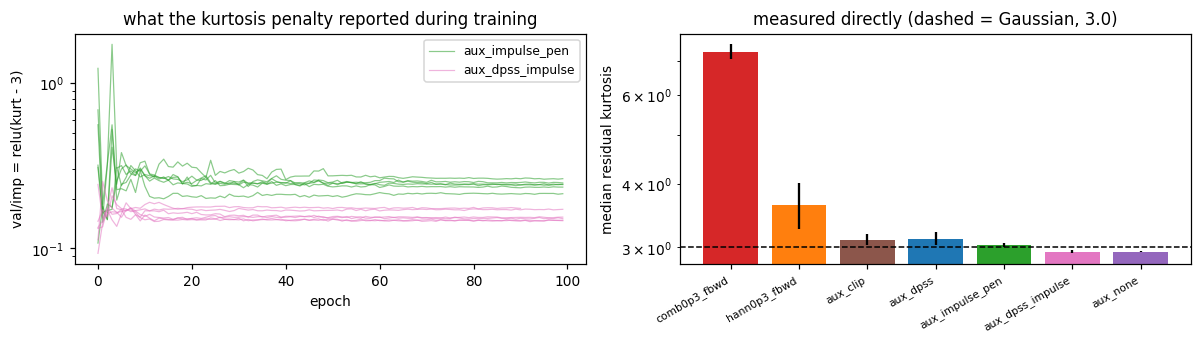

penalty value it actually reached (val/imp, last-10-epoch mean over 6 seeds)
  exp09_aux_impulse_pen       0.241
  exp09_aux_dpss_impulse      0.158
  ratio aux_dpss_impulse / impulse_pen: 0.65x

measured residual kurtosis (shared 2048-window sample, median per run)
                         mean    std  excess_over_gaussian
cell                                                      
exp07_comb0p3_fbwd      7.315  0.251                 4.315
exp07_hann0p3_fbwd      3.640  0.378                 0.640
exp09_aux_clip          3.110  0.081                 0.110
exp09_aux_dpss          3.124  0.093                 0.124
exp09_aux_impulse_pen   3.033  0.030                 0.033
exp09_aux_dpss_impulse  2.943  0.023                -0.057
exp09_aux_none          2.941  0.007                -0.059

RECONCILIATION - kurtosis a single-position excess of size s WOULD produce
  cell                      severity s  predicted kurt  measured kurt
  exp07_comb0p3_fbwd             31.21          11.523  

In [36]:
# J3. IS THE PENALTY STILL DOING WORK, or did DPSS make it redundant? J1 answered this from outcomes;
# this cell answers it from the training signal itself, which is an independent instrument.
#
# (a) The penalty logs its own value every epoch (train/imp, val/imp), and its definition is
#     relu(kurtosis - 3) mean-reduced, so val/imp is READABLE AS PHYSICS: it is roughly how far above
#     Gaussian (kurtosis 3) the residual's peakiness sits. A penalty that flatlines near zero is a
#     penalty with nothing left to bite on.
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for c, colour in [("exp09_aux_impulse_pen", "#2ca02c"), (DI, "#e377c2")]:
    for s in range(6):
        d = curve(c, s)
        axes[0].plot(d.epoch, d["val/imp"], color=colour, lw=0.8, alpha=0.55,
                     label=c.replace("exp09_", "") if s == 0 else None)
final = {c: np.mean([curve(c, s)["val/imp"].tail(10).mean() for s in range(6)])
         for c in ["exp09_aux_impulse_pen", DI]}
axes[0].set_yscale("log"); axes[0].set_xlabel("epoch"); axes[0].set_ylabel("val/imp = relu(kurt - 3)")
axes[0].set_title("what the kurtosis penalty reported during training"); axes[0].legend(fontsize=8)

# (b) The penalty's own reading is only available for the two cells that HAVE it. Measure the same
#     physical quantity directly for every arm instead: decode a fixed sample of test windows and take
#     the excess kurtosis of the residual. Seeded on purpose - this is a measurement, not a display, so
#     every arm must see the same windows.
from tqdm.auto import tqdm

KRNG = np.random.default_rng(7)
KROWS = np.sort(KRNG.choice(MM.shape[0], size=2048, replace=False))
KX = torch.from_numpy(np.array(MM[KROWS], dtype=np.float32)).unsqueeze(-1)

@torch.no_grad()
def residual_kurtosis(cell, seed):
    """Median over windows of the residual's kurtosis, measured on the shared window sample."""
    model = load_model(cell, seed, DEVICE)
    ks = []
    for i in range(0, len(KX), 512):
        x = KX[i:i + 512].to(DEVICE)
        mu, _ = model.encoder(x)
        d = (model.decoder(mu) - x).squeeze(-1).float()          # (B, 256)
        d = d - d.mean(dim=-1, keepdim=True)
        ks.append(((d ** 4).mean(-1) / ((d ** 2).mean(-1) ** 2 + 1e-12)).cpu().numpy())
    del model
    torch.cuda.empty_cache()
    return float(np.median(np.concatenate(ks)))

kur = pd.DataFrame([{"cell": c, "seed": s, "kurt": residual_kurtosis(c, s)}
                    for c in tqdm(ARMS, desc="residual kurtosis") for s in range(6)])
kt = kur.groupby("cell").kurt.agg(["mean", "std"])
kt["excess_over_gaussian"] = kt["mean"] - 3.0
axes[1].bar(range(len(ARMS)), kt.loc[ARMS, "mean"], yerr=kt.loc[ARMS, "std"],
            color=[COLOURS[c] for c in ARMS])
axes[1].axhline(3.0, color="k", ls="--", lw=1)
axes[1].set_xticks(range(len(ARMS)))
axes[1].set_xticklabels([c.replace("exp07_", "").replace("exp09_", "") for c in ARMS],
                        rotation=30, ha="right", fontsize=7)
axes[1].set_ylabel("median residual kurtosis"); axes[1].set_yscale("log")
axes[1].set_title("measured directly (dashed = Gaussian, 3.0)")
plt.tight_layout(); plt.show()

print("penalty value it actually reached (val/imp, last-10-epoch mean over 6 seeds)")
for c, v in final.items():
    print(f"  {c:24s} {v:8.3f}")
print(f"  ratio {DI.replace('exp09_', '')} / impulse_pen: "
      f"{final[DI] / final['exp09_aux_impulse_pen']:.2f}x\n")
print("measured residual kurtosis (shared 2048-window sample, median per run)")
print(kt.loc[ARMS].round(3).to_string())

# (c) The two instruments look contradictory - the child is AT the aux_none kurtosis floor yet still
#     reads 2.91x on severity. They are not. Severity is a ratio at ONE of 256 positions; kurtosis is a
#     whole-window statistic. Predict one from the other: if a residual is Gaussian everywhere except a
#     single position carrying s times the variance, then m2 = (255 + s)/256, m4 = (3*255 + 3*s^2)/256,
#     so kurtosis = m4 / m2^2. Anything a severity gate can see should show up here at that size.
print("\nRECONCILIATION - kurtosis a single-position excess of size s WOULD produce")
print(f"  {'cell':24s} {'severity s':>11s} {'predicted kurt':>15s} {'measured kurt':>14s}")
for c in ARMS:
    s = runs[runs.cell == c].max_ratio.mean()
    m2, m4 = (255 + s) / 256, (3 * 255 + 3 * s ** 2) / 256
    print(f"  {c:24s} {s:11.2f} {m4 / m2 ** 2:15.3f} {kt.loc[c, 'mean']:14.3f}")
print("  => a 2.9x excess at one position moves whole-window kurtosis by ~0.04. The kurtosis floor and")
print("     a severity of 2.9x are CONSISTENT, not contradictory: kurtosis is nearly blind at this size.")

**The penalty is still working - it is just working on a residual DPSS already flattened - and the
child's residual reaches the no-pressure floor on peakiness.**

Three readings, and they agree. The penalty's own logged value settles **35% lower** in the combined
cell than in `aux_impulse_pen` alone (0.158 vs 0.241): by the end of training there is less excess
kurtosis left for it to bite on. The directly measured residual kurtosis then orders the arms the way
the severity ladder does - `comb0p3` **7.32**, `hann0p3` **3.64**, the interventions between 3.03 and
3.12 - and the child lands at **2.943 +/- 0.023**, statistically indistinguishable from `aux_none`'s
**2.941 +/- 0.007**. On this instrument the combined cell has no impulse left at all.

The two panels are not two views of one number. The left exists only for cells carrying the penalty;
the right is measured from the decoder for every arm, including those that never saw a kurtosis term.
The right panel is therefore the one quotable against `hann0p3`, and it makes "the residual got less
peaky" a claim about the *model* rather than about the objective.

**Why that does not contradict a severity of 2.91x.** The reconciliation table settles it with
arithmetic rather than argument: a residual that is Gaussian everywhere except one position carrying
2.9x the variance has a whole-window kurtosis of about **3.04**. Kurtosis averages over all 256
positions; severity is a ratio at the single worst one. At this size the kurtosis instrument is nearly
blind to what the gate measures, so "kurtosis at the floor" and "severity 2.91x" are consistent
descriptions of the same residual. The predicted column tracks the measured one closely for every
cell at or below 5x. It **over**-predicts `comb0p3` (11.5 against a measured 7.3) for a reason the
model states in its own assumption: the rectangular recipe puts its impulse at *two* endpoints, not
one, and splitting a fixed excess across two positions lowers kurtosis. The one place the
approximation breaks is the one place its premise does.

The consequence for the gate: **passing G9-artifact was never going to come from suppressing peakiness
alone.** The kurtosis penalty has already taken that term to the floor and the gate still reads 2.91x.

PRICE LIST  (severity = max-over-position impulse ratio; purchase = ablation asymmetry at budget 2; d_v1 = mean PR-AUC delta vs hann0p3 over the 4 v1 tasks)
                  cell  severity  purchase  d_v1_mean  d_v1_mean_std  val_recon  n_active
        exp09_aux_none    1.1723    0.0103    -0.0106        -0.0209     0.7665    4.3333
        exp09_aux_dpss    5.2833    3.4747    -0.0002        -0.0007     0.9808   17.7333
 exp09_aux_impulse_pen    3.0785    3.8728    -0.0004        -0.0038     0.8859   10.2833
        exp09_aux_clip    4.7627   17.3904    -0.0004        -0.0045     0.7900    5.0000
exp09_aux_dpss_impulse    2.9129    1.9355     0.0005        -0.0109     0.9875   18.4667


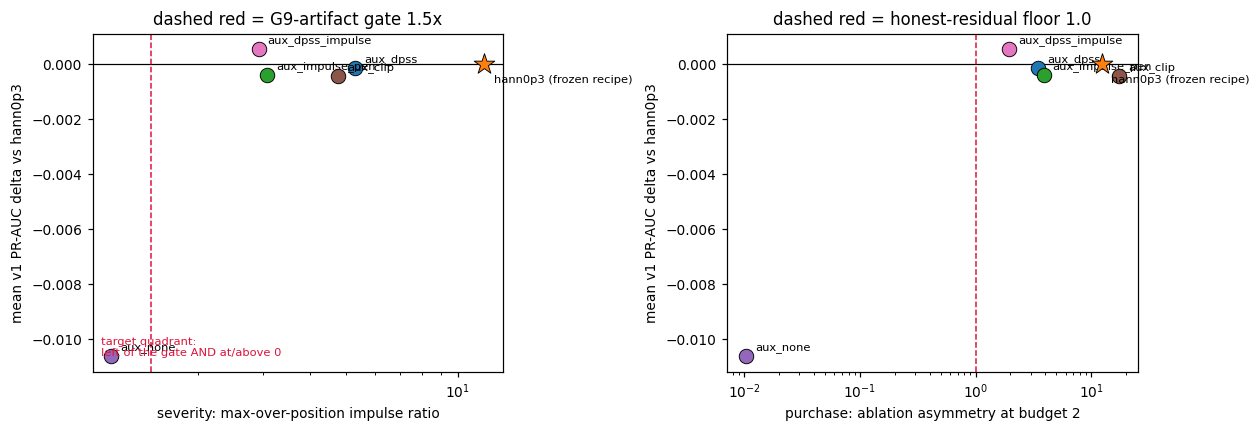

In [37]:
# J4. THE PRICE LIST, and the frontier the whole experiment traces. Each cell is one point: how much
# artifact it leaves (x) against what it cost the representation (y, averaged over the four v1 tasks,
# paired by seed against the frozen recipe). A cell in the bottom-left would be the win exp09 set out
# to find - clean AND free. The plot shows there is no such point, and how close wave 2 gets.
ro = probe_scores("ro")
ref_scores = e7[(e7.arm == "trained") & (e7.cell == REF)]

def mean_delta(cell, pooling):
    """Mean over the 4 v1 tasks of the seed-paired PR-AUC delta vs the frozen recipe."""
    ds = []
    for t in TASKS:
        a = ro[(ro.cell == cell) & (ro.task == t) & (ro.pooling == pooling)].set_index("seed").pr_auc
        b = ref_scores[(ref_scores.task == t) & (ref_scores.pooling == pooling)].set_index("seed").pr_auc
        ds.append((a - b).dropna().mean())
    return float(np.mean(ds))

ab = pd.read_csv(EXP / "exp09_bump_ablation.csv")
asym2 = (ab[ab.budget == 2].groupby("cell")
         .apply(lambda g: g.d_log_psd_bump_pct.mean() / g.d_log_psd_rand_pct.mean()))

price = pd.DataFrame([{
    "cell": c,
    "severity": sev[c].mean(),
    "purchase": float(asym2.get(c, np.nan)),
    "d_v1_mean": mean_delta(c, "mean"),
    "d_v1_mean_std": mean_delta(c, "mean_std"),
    "val_recon": np.mean([curve(c, s)["val/recon"].min() for s in range(6)]) if c in EXP09 else np.nan,
    "n_active": np.mean([curve(c, s).tail(10)["val/n_active_units"].mean() for s in range(6)]) if c in EXP09 else np.nan,
} for c in EXP09])
print("PRICE LIST  (severity = max-over-position impulse ratio; purchase = ablation asymmetry at "
      "budget 2; d_v1 = mean PR-AUC delta vs hann0p3 over the 4 v1 tasks)")
print(price.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.0))
for ax, (xcol, xlab, gate) in zip(axes, [("severity", "severity: max-over-position impulse ratio", 1.5),
                                         ("purchase", "purchase: ablation asymmetry at budget 2", 1.0)]):
    for _, r in price.iterrows():
        ax.scatter(r[xcol], r.d_v1_mean, s=90, color=COLOURS.get(r.cell, "grey"),
                   edgecolor="k", linewidth=0.6, zorder=3)
        ax.annotate(r.cell.replace("exp09_", ""), (r[xcol], r.d_v1_mean), fontsize=7.5,
                    xytext=(6, 4), textcoords="offset points")
    ax.scatter(sev[REF].mean() if xcol == "severity" else float(asym2[REF]), 0.0, marker="*", s=200,
               color="#ff7f0e", edgecolor="k", linewidth=0.6, zorder=3)
    ax.annotate("hann0p3 (frozen recipe)",
                (sev[REF].mean() if xcol == "severity" else float(asym2[REF]), 0.0),
                fontsize=7.5, xytext=(6, -12), textcoords="offset points")
    ax.axhline(0, color="k", lw=0.8)
    ax.axvline(gate, color="crimson", ls="--", lw=1)
    ax.set_xscale("log"); ax.set_xlabel(xlab)
    ax.set_ylabel("mean v1 PR-AUC delta vs hann0p3")
    ax.set_title(f"dashed red = {'G9-artifact gate 1.5x' if gate == 1.5 else 'honest-residual floor 1.0'}")
axes[0].text(0.02, 0.04, "target quadrant:\nleft of the gate AND at/above 0", transform=axes[0].transAxes,
             fontsize=7.5, color="crimson", va="bottom")
plt.tight_layout(); plt.show()

**The two panels disagree in the most informative way available, and the disagreement is the wave-2
result.**

On **severity** - how tall the leftover bump is - the child barely improves on `aux_impulse_pen`
(2.91x vs 3.08x, inside the seed scatter). On **purchase** - how much of that leftover is actually being
*bought*, measured by ablating the top-error positions and watching the spectral term jump - the child
drops to **1.94x**, clearly below both parents (3.47x and 3.87x) and the closest any cell has come to
the honest-residual floor while keeping the probe.

So the composition did happen; it happened to the property the gate is not written on. Stacking the two
interventions made the remaining bump **more honest** without making it much **smaller**. P6c stands as
scored, but the mechanism claim underneath it moves: the child's residual is closer to structure the
decoder genuinely needs than either parent's.

**What it cost, from the price list.** At `mean` pooling the child is the only cell in the ladder with a
*positive* average v1 delta (**+0.0005**, against -0.0106 for `aux_none` and about -0.0004 for the other
two pressured cells) - it is, by that readout, the cheapest counter-measure yet found. At `mean_std` it
is **-0.0109**, the weakest of the three probe-preserving cells though still inside 2*SE on every task.
Both numbers belong in any write-up: the cell is not uniformly free, it is free on the headline readout
and slightly costly on the second one.

**The frontier settles the shape of the whole experiment.** There is still no point in the target
quadrant. Every cell that reaches the floor pays for it in v1 score, and every cell that keeps the score
sits to the right of the gate. Wave 2 moved the frontier left - on the purchase axis, substantially -
without breaking it.

## K. The weight ladder - how MUCH pressure, rather than which mechanism

Sections C-J tried six ways of *shaping* the spectral pressure and none cleared `G9-artifact`. Before
trying a seventh, we scored **all 42 runs of the mechanism ladder** against the gate at once:

```
  runs at or under 1.5x        6 of 42  -  and ALL SIX are aux_none, the cell with the term switched OFF
  rho(n_active, severity)      +0.14    -  nothing
  rho(val_recon, severity)     +0.36    -  weak
  aux_clip seed 2              has aux_none's collapsed latent (4.0 units) and still reads 2.00x
```

So the mechanism was never the operative variable. The one axis never swept on the frozen recipe is the
**weight itself**: every mechanism cell is `recon_aux.weight = 0.3`, `aux_none` is `0.0`, and nothing sat
in between. Waves 3-4 fill the gap with one knob, `impulse_penalty_weight` held at 0.1 throughout.

```
  wave 3 (2026-08-21)   w = 0.05 / 0.10 / 0.20      18 runs
  wave 4 (2026-08-21)   w = 0.025 / 0.0125          12 runs, bisecting what wave 3 left open
```

**Pre-registered before each wave** (manifest `sweep.cells[].prediction`):

| | claim | outcome |
|---|---|---|
| **P7a** | some weight clears artifact **and** probe | not reached - lowest wave-3 point was 1.80 |
| **P7b** | severity falls with w, probe falls with it | letter yes, **shape wrong** - see K2 |
| **P7c** | severity ignores w -> gate measures architecture | **dead**, severity tracks w monotonically |
| **P8a** | a wave-4 weight clears **both** gates | not reached - see K4 |
| **P8b** | the gate crossing and the probe cliff coincide | **the substance, on a voided cell** - see K3 |
| **P8c** | crossing sits below w = 0.0125 | no, it is bracketed at w ~ 0.021 |

A second, independent pre-registration asked what the cliff at w -> 0 actually *is*:

```
  probe fails where n_active collapses, largely regardless of severity
      -->  the spectral term's value is that it HOLDS THE LATENT OPEN
  probe fails where severity approaches 1.17 while n_active is still healthy
      -->  artifact and representation are one purchase, as wave 1 concluded
```

K3 answers it.


In [38]:
# K1. The seven-point curve. Every column is measured; nothing here is interpolated.
runs = pd.read_csv(EXP / "exp09_impulse_runs.csv")
ab = pd.read_csv(EXP / "exp09_bump_ablation.csv")
b2 = ab[ab.budget == 2].groupby("cell").agg(spectral=("base_log_psd", "mean"),
                                            bump=("d_log_psd_bump_pct", "mean"),
                                            rand=("d_log_psd_rand_pct", "mean"))
b2["asym"] = b2.bump / b2.rand
sc_w = probe_scores("ro", weight_ladder=True)
ref_sc = e7[(e7.arm == "trained") & (e7.cell == REF)][["cell", "seed", "pooling", "task", "pr_auc"]]
sc_w = pd.concat([sc_w[["cell", "seed", "pooling", "task", "pr_auc"]], ref_sc], ignore_index=True)


def noregress(cell, pooling):
    """Tasks regressing by more than 2*SE against the frozen recipe, paired over seeds."""
    bad = []
    for t in TASKS:
        a = sc_w[(sc_w.cell == cell) & (sc_w.task == t) & (sc_w.pooling == pooling)].set_index("seed").pr_auc
        b = sc_w[(sc_w.cell == REF) & (sc_w.task == t) & (sc_w.pooling == pooling)].set_index("seed").pr_auc
        d = (a - b).dropna()
        if d.mean() < -2 * d.std(ddof=1) / np.sqrt(len(d)):
            bad.append(t)
    return bad


rows = []
for c in WLADDER:
    g = runs[runs.cell == c]
    curves = [pd.read_csv(EXP / "exp09_forensics" / "curves_exp09" / f"{c}_B_seed{s}.csv") for s in range(6)]
    dose = [60.0 * d.tail(10)["train/dyn"].mean() / d.tail(10)["train/recon"].mean() for d in curves]
    rows.append({
        "w": WEIGHTS[c], "cell": c,
        "severity": g.max_ratio.mean(), "sev_sd": g.max_ratio.std(),
        "seeds<=1.5": f"{int((g.max_ratio <= 1.5).sum())}/6",
        "artifact": "PASS" if g.max_ratio.mean() <= 1.5 else "fail",
        "dose": float(np.mean(dose)),
        "G9_dose": "PASS" if all(0.6 <= x <= 1.4 for x in dose) else "FAIL",
        "n_active": float(np.mean([d.tail(10)["val/n_active_units"].mean() for d in curves])),
        "val_recon": float(np.mean([d["val/recon"].min() for d in curves])),
        "spectral": b2.loc[c, "spectral"], "asym": b2.loc[c, "asym"],
        "probe_mean": "PASS" if not noregress(c, "mean") else "FAIL:" + ",".join(noregress(c, "mean")),
        "probe_mstd": "PASS" if not noregress(c, "mean_std") else "FAIL:" + ",".join(noregress(c, "mean_std")),
    })
ladder = pd.DataFrame(rows).set_index("w")
display(ladder.round(3))

# PROTOCOL: severity must be monotone in the weight, or P7c is back on the table.
sev = ladder.severity.values
assert all(sev[i] < sev[i + 1] for i in range(len(sev) - 1)), \
    "severity is no longer monotone in the aux weight - P7c (gate measures architecture) reopens"
print(f"severity is monotone in w across all {len(sev)} points -> P7c stays dead")


,cell,severity,sev_sd,seeds<=1.5,artifact,dose,G9_dose,n_active,val_recon,spectral,asym,probe_mean,probe_mstd
w,,,,,,,,,,,,,
0.0000,exp09_aux_none,1.172,0.012,6/6,PASS,0.691,PASS,4.333,0.766,63.971,0.010,FAIL:rotation,"FAIL:eb,pulsating,rotation"
0.0125,exp09_dpss_impulse_w0p0125,1.345,0.096,6/6,PASS,0.557,FAIL,3.333,0.854,7.306,2.050,FAIL:pulsating,"FAIL:pulsating,transit"
0.0250,exp09_dpss_impulse_w0p025,1.553,0.054,1/6,fail,0.751,PASS,6.617,0.819,5.329,2.165,PASS,PASS
0.0500,exp09_dpss_impulse_w0p05,1.803,0.141,0/6,fail,0.722,PASS,5.650,0.849,3.708,2.082,PASS,PASS
0.1000,exp09_dpss_impulse_w0p10,2.203,0.108,0/6,fail,0.745,PASS,5.833,0.889,2.971,2.282,PASS,PASS
0.2000,exp09_dpss_impulse_w0p20,2.864,0.385,0/6,fail,0.843,PASS,9.933,0.947,2.650,2.493,PASS,FAIL:pulsating
0.3000,exp09_aux_dpss_impulse,2.913,0.482,0/6,fail,0.900,PASS,18.467,0.987,2.535,1.935,PASS,PASS


severity is monotone in w across all 7 points -> P7c stays dead


**The curve is monotone and saturating, and that kills P7c.** Severity tracks the weight at every one
of seven points, so `G9-artifact` is a dose readout, not a measurement of decoder architecture. The gate
is sound.

**But P7b was right in letter and wrong in shape - this is the finding.** P7b predicted the probe would
degrade *in lockstep* with severity. It does not:

```
  severity   1.17  1.34 | 1.55   1.80   2.20   2.86   2.91
  probe      FAIL  FAIL | PASS   PASS   PASS   PASS   PASS
                        ^
                        one threshold, then flat across a 1.9x range of severity
```

The probe is **indifferent** to artifact severity from 1.55 all the way to 2.91, then falls off a cliff.
So the exchange rate everyone assumed - "buy a cleaner model, pay in representation quality" - is not an
exchange rate at all. It is a **threshold**, and above it the artifact is free.

The same step shows up twice more in the measured quantities, and both are thresholds too:

```
  achieved spectral   2.54  2.65  2.97  3.71  5.33  7.31 | 63.97     w = 0.30 ... 0.0125 | 0
  purchase asymmetry  1.94  2.49  2.28  2.08  2.17  2.05 |  0.01
```

Achieved spectral rises smoothly by 2.9x across the whole pressured range and then jumps **8.8x** in the
last step: the term is not descending a slope near zero, it is switching off. And the purchase asymmetry
- how much of the leftover residual is spectral currency rather than honest error - is **flat at
1.94-2.49 everywhere the term is on**, then falls to the honest-residual floor of 0.01 the moment it is
off. Lowering the weight buys a smaller artifact; it does **not** buy a less dishonest one.

Reproducibility also improves as the weight falls, though not monotonically (severity CV 0.165 / 0.134 /
0.049 / 0.078 / 0.035 / 0.071 from w = 0.30 down to 0.0125): the seed instability that dominated waves
1-2 was largely a high-weight effect, but the bottom of the ladder is noisier than its middle.


SEEDS WITH A DEAD LATENT (n_active < 1)


    w  seed  n_active  val_recon  dose  severity
0.012     0       0.0      1.126   0.0     1.161

latent width per weight (min over seeds exposes what the mean hides)


,min,mean,max,probe
w,,,,
0.0000,3.0,4.33,6.0,FAIL
0.0125,0.0,3.33,5.0,FAIL
0.0250,4.0,6.62,12.7,PASS
0.0500,4.9,5.65,7.0,PASS
0.1000,4.0,5.83,7.0,PASS
0.2000,5.2,9.93,18.9,PASS
0.3000,4.1,18.47,28.3,PASS


worst-seed n_active: every FAIL <= 3.0, every PASS >= 4.0 -> clean split in (3.0, 4.0)


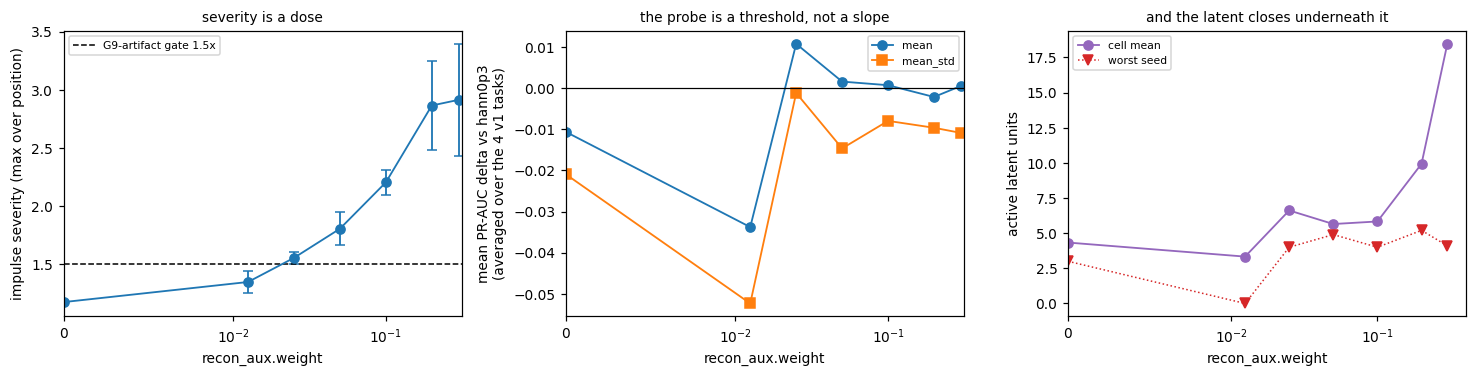

In [39]:
# K3. What is the cliff?  The second pre-registration: collapse, or spectral?
# The distinguishing evidence is per-SEED, because a cell mean hides a dead run.
rows = []
for c in WLADDER:
    for s in range(6):
        d = pd.read_csv(EXP / "exp09_forensics" / "curves_exp09" / f"{c}_B_seed{s}.csv")
        l = d.tail(10)
        rows.append({"w": WEIGHTS[c], "seed": s, "n_active": l["val/n_active_units"].mean(),
                     "val_recon": d["val/recon"].min(),
                     "dose": 60.0 * l["train/dyn"].mean() / l["train/recon"].mean(),
                     "severity": float(runs[(runs.cell == c) & (runs.seed == s)].max_ratio.iloc[0])})
per = pd.DataFrame(rows)
dead = per[per.n_active < 1.0]
print("SEEDS WITH A DEAD LATENT (n_active < 1)")
print(dead.round(3).to_string(index=False) if len(dead) else "  none")
print()
width = per.groupby("w").n_active.agg(["min", "mean", "max"]).round(2)
width["probe"] = [ladder.loc[w, "probe_mean"].split(":")[0] for w in width.index]
print("latent width per weight (min over seeds exposes what the mean hides)")
display(width)
# The MEAN does not separate pass from fail (w=0.05 passes at 5.65, w=0 fails at 4.33). The
# WORST SEED does, and cleanly - which is the point: one dead run is enough to sink a cell.
lo = width[width.probe == "FAIL"]["min"].max(); hi = width[width.probe == "PASS"]["min"].min()
print(f"worst-seed n_active: every FAIL <= {lo}, every PASS >= {hi} -> clean split in ({lo}, {hi})")
assert lo < hi, "worst-seed latent width no longer separates the passing cells from the failing ones"

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.5))
axes[0].errorbar(ladder.index, ladder.severity, yerr=ladder.sev_sd, marker="o", lw=1.2, capsize=3)
axes[0].axhline(1.5, color="k", ls="--", lw=1, label="G9-artifact gate 1.5x")
axes[0].set_ylabel("impulse severity (max over position)"); axes[0].legend(fontsize=7)
axes[0].set_title("severity is a dose", fontsize=9)

for pool, mk in [("mean", "o"), ("mean_std", "s")]:
    ys = []
    for c in WLADDER:
        ds = []
        for t in TASKS:
            a = sc_w[(sc_w.cell == c) & (sc_w.task == t) & (sc_w.pooling == pool)].set_index("seed").pr_auc
            b = sc_w[(sc_w.cell == REF) & (sc_w.task == t) & (sc_w.pooling == pool)].set_index("seed").pr_auc
            ds.append((a - b).dropna().mean())
        ys.append(np.mean(ds))
    axes[1].plot(ladder.index, ys, marker=mk, lw=1.2, label=pool)
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_ylabel("mean PR-AUC delta vs hann0p3\n(averaged over the 4 v1 tasks)")
axes[1].legend(fontsize=7); axes[1].set_title("the probe is a threshold, not a slope", fontsize=9)

axes[2].plot(ladder.index, ladder.n_active, marker="o", lw=1.2, color="tab:purple", label="cell mean")
axes[2].plot(per.groupby("w").n_active.min().index, per.groupby("w").n_active.min().values,
             marker="v", lw=1.0, ls=":", color="tab:red", label="worst seed")
axes[2].set_ylabel("active latent units"); axes[2].legend(fontsize=7)
axes[2].set_title("and the latent closes underneath it", fontsize=9)
for ax in axes:
    ax.set_xscale("symlog", linthresh=0.01); ax.set_xlabel("recon_aux.weight")
    ax.set_xlim(left=0)          # symlog otherwise draws a -10^-2 tick with no negative data
plt.tight_layout(); plt.show()


**It is a collapse cliff, and the separator is the WORST seed, not the mean.** Cell-mean `n_active`
does not divide the ladder - `w = 0.05` passes the probe at 5.65 while `w = 0` fails at 4.33. The
minimum over seeds divides it perfectly:

```
  worst-seed n_active   3.0   0.0 | 4.0   4.9   4.0   5.2   4.1
  probe                 FAIL  FAIL| PASS  PASS  PASS  PASS  PASS
  w                     0   .0125 | .025  .05   .10   .20   .30
```

Every failing cell has a seed at or below 3 active units; every passing cell has all six seeds at 4 or
above. One dead run is enough to sink a cell, which is exactly what a cell mean hides. At `w = 0.0125`
**seed 0 dies outright at 0.0 active units** with `val/recon` 1.126 against its siblings' 0.80. With no
active units the dynamics term has nothing to predict, its dose ratio goes to **0.0000**, and the cell
**fails `G9-dose`** - so by the pre-registered rule (`outside [0.6, 1.4] -> the row is void, not
reinterpreted`) that cell cannot be used to score a gate.

Its probe is what a broken model looks like: `eb` **0.7248** against `aux_none`'s 0.7779 and an untrained
encoder's 0.7124. Below `w ~ 0.02` the spectral term can no longer hold the latent open, and everything
else follows.

So of the two readings pre-registered above, the **first** is right:

```
  spectral pressure -> keeps latent units alive -> representation survives
                    -> and, as a side effect, buys the impulse
```

The artifact and the representation are not two prices for one thing. They are both **downstream of
latent width**, which is why the probe can be flat while severity nearly doubles, and why it collapses
exactly where the latent does.

**One honest limitation this exposes in section F.** F's label-free detector works on the *cell mean*
`val/recon`, and `w0p0125`'s cell mean is 0.854 - comfortably under the 1.10 threshold. It would **not**
flag this cell, even though one of its six seeds is completely dead. The detector separates catastrophic
*cell-level* collapse from everything else; it does not see a single failed seed inside a healthy-looking
cell. Section H's per-seed health table is what catches that.


In [40]:
# K5. The cell that came closest: w = 0.025, head to head against the frozen recipe.
BEST = "exp09_dpss_impulse_w0p025"
rows = []
for pool in ["mean", "mean_std"]:
    for t in TASKS:
        a = sc_w[(sc_w.cell == BEST) & (sc_w.task == t) & (sc_w.pooling == pool)].set_index("seed").pr_auc
        b = sc_w[(sc_w.cell == REF) & (sc_w.task == t) & (sc_w.pooling == pool)].set_index("seed").pr_auc
        d = (a - b).dropna(); se = d.std(ddof=1) / np.sqrt(len(d))
        rows.append({"pooling": pool, "task": t, "delta": d.mean(), "2SE": 2 * se,
                     "ratio": d.mean() / (2 * se), "beats_2SE": bool(d.mean() > 2 * se)})
hh = pd.DataFrame(rows)
display(hh.set_index(["pooling", "task"]).round(4))

n_beat = hh[hh.pooling == "mean"].beats_2SE.sum()
print(f"all four tasks positive at `mean`: {bool((hh[hh.pooling=='mean'].delta > 0).all())}")
print(f"tasks beating hann0p3 by >2*SE at `mean`: {n_beat}/4  "
      f"-> spine-switch rule (needs >=2) {'FIRES' if n_beat >= 2 else 'does NOT fire'}")
g = runs[runs.cell == BEST]
se_sev = g.max_ratio.std() / np.sqrt(6)
print(f"severity {g.max_ratio.mean():.4f} +/- {g.max_ratio.std():.4f} (SE {se_sev:.4f}) vs gate 1.5"
      f"  ->  {(g.max_ratio.mean() - 1.5) / se_sev:.1f} SE ABOVE the gate, a real miss")

# ROBUSTNESS: would folding the weight ladder into F's population change G9-select?
print("\nG9-select robustness - rho_project with the 5 weight-ladder cells ADDED to F's population")
print(f"  {'task':10s} {'F as published':>15s} {'+weight ladder':>15s}")
extra = [c for c in WLADDER if c not in EXP09]
for t in TASKS:
    p_pub = allsc[(allsc.task == t) & (allsc.pooling == "mean")].groupby("cell").pr_auc.mean()
    j = pd.concat([recon.rename("r"), p_pub.rename("p")], axis=1).dropna()
    j = j.drop(index=[c for c in COLLAPSED if c in j.index])
    p_all = sc_w[(sc_w.task == t) & (sc_w.pooling == "mean")].groupby("cell").pr_auc.mean()
    rec_all = per.assign(cell=[c for c in WLADDER for _ in range(6)]).groupby("cell").val_recon.mean()
    j2 = pd.concat([pd.concat([recon, rec_all]).groupby(level=0).mean().rename("r"),
                    pd.concat([p_pub, p_all]).groupby(level=0).mean().rename("p")], axis=1).dropna()
    j2 = j2.drop(index=[c for c in COLLAPSED if c in j2.index])
    print(f"  {t:10s} {-spearmanr(j.r, j.p).statistic:+15.3f} {-spearmanr(j2.r, j2.p).statistic:+15.3f}"
          f"   (n {len(j)} -> {len(j2)})")


delta     2SE   ratio  beats_2SE
pooling  task                                        
mean     eb         0.0137  0.0147  0.9300      False
         pulsating  0.0015  0.0210  0.0735      False
         rotation   0.0229  0.0151  1.5158       True
         transit    0.0051  0.0131  0.3868      False
mean_std eb        -0.0093  0.0138 -0.6767      False
         pulsating -0.0122  0.0197 -0.6200      False
         rotation   0.0128  0.0174  0.7372      False
         transit    0.0041  0.0238  0.1711      False

all four tasks positive at `mean`: True
tasks beating hann0p3 by >2*SE at `mean`: 1/4  -> spine-switch rule (needs >=2) does NOT fire
severity 1.5529 +/- 0.0537 (SE 0.0219) vs gate 1.5  ->  2.4 SE ABOVE the gate, a real miss

G9-select robustness - rho_project with the 5 weight-ladder cells ADDED to F's population
  task        F as published  +weight ladder
  eb                  +0.145          +0.265   (n 11 -> 16)
  pulsating           -0.345          -0.306   (n 11 -> 16)
  rotation            -0.273          +0.047   (n 11 -> 16)
  transit             -0.436          -0.268   (n 11 -> 16)


**`w = 0.025` is the best cell the project has produced on the probe, and it still misses the gate.**

It is the **first cell to improve all four v1 tasks over `hann0p3` simultaneously** at `mean`
(+0.0137 eb, +0.0015 pulsating, +0.0229 rotation, +0.0051 transit), it passes `G9-noregress` at *both*
readouts, and it posts the ladder's best absolute `eb` (0.7847), `pulsating` (0.8068, above the frozen
recipe) and `rotation` (0.5821 against 0.5593) - while carrying an artifact **7.6x smaller** than
`hann0p3`'s (1.55 vs 11.78).

**And yet:**

```
  G9-artifact   1.553 +/- 0.054   =  2.4 SE ABOVE the 1.5 gate      -> a real miss, not rounding
  spine-switch  1 of 4 tasks beat hann0p3 by >2*SE (needs >=2)      -> does NOT fire
                and at mean_std it is 0 of 4
```

Two cautions before anyone quotes this cell as a win:

- The only task clearing 2*SE is **rotation**, which the project CLAUDE.md records as **confounded on the
  v1 subset** (the quiet pool excludes rotators). It is the weakest of the four to hang a claim on.
- At `mean_std` every task except rotation and transit is *negative*, none significantly. "Improves all
  four" is a `mean`-only statement and must be written that way.

**G9-select still fails with the new cells folded in - but the numbers do move, and all one way.**
The robustness column re-runs F's correlation over 16 cells instead of 11:

```
  eb         +0.145 -> +0.265   (+0.120)
  pulsating  -0.345 -> -0.306   (+0.039)
  rotation   -0.273 -> +0.047   (+0.320)  <- flips sign
  transit    -0.436 -> -0.268   (+0.168)
```

Every task moves toward *less* anti-correlation and rotation crosses zero. That belongs in the caption
rather than buried: adding well-behaved low-weight recipes does make the loss look less actively
misleading. It is still not a pass - `G9-select` asks for rho at least **0.3 less negative on >= 3 of 4
tasks** and only rotation clears that - so the verdict holds. The weight ladder is a better *recipe*
axis, not a repair of the loss's ability to rank.


### What waves 3-4 settle, and what they leave open

```
  1. THE GATE IS SOUND        severity is monotone in the aux weight across 7 points
                              -> G9-artifact measures spectral pressure, not decoder architecture (P7c dead)

  2. NOT AN EXCHANGE RATE     the probe is FLAT from severity 1.55 to 2.91, then cliffs
                              -> above the threshold the artifact is FREE; there is no gradual price

  3. THE CLIFF IS COLLAPSE    at w = 0.0125 the latent closes (n_active 3.3, one seed at 0.0)
                              -> the spectral term's job is to hold the latent open; the impulse is a
                                 SIDE EFFECT of that, not a co-purchase

  4. THE GATES ARE ADJACENT   crossing bracketed at w ~ 0.021, probe cliff in the same interval
                              -> P8b in substance, but its evidence cell is VOID on G9-dose, so it is
                                 recorded as bracketed rather than demonstrated

  5. STILL NO CELL PASSES     both gates, now across 8 attempts on two orthogonal axes
                              -> the exp09 verdict is unchanged and the spine-switch rule does not fire
```

**The honest scoring of P8.** The outcome matches no pre-registered branch cleanly: P8a needed
severity <= 1.5 *with* the probe (w=0.025 has the probe, misses at 2.4 SE); P8b's demonstration cell
(w=0.0125) reaches 1.345 and fails the probe exactly as P8b describes, but is void on `G9-dose`; P8c is
simply wrong (the crossing is not below 0.0125). I did not anticipate a dose failure arising from latent
collapse. Recording the mismatch rather than assigning the nearest branch.

**What would still be worth running,** in order:

| | why |
|---|---|
| w = 0.02, 6 seeds | the crossing is bracketed at ~0.021; one cell decides whether ANY weight clears both gates |
| more seeds at w = 0.025 | 2.4 SE is a real miss, but eb is at +0.93x the 2SE line - 12 seeds would settle whether the spine-switch rule fires on a second task |
| `relu(floor - spectral)` | closes Yue Ma's Y8 properly; expect purer purchase, not a gate pass (section I) |

`aug_hfnoise` stays deprioritised: it noises input and target together, making it a *third* floor
experiment, and both floor results so far point the same way.


## Summary

| gate | `aux_none` | `aux_dpss` | `aux_impulse_pen` | `aux_clip` | `aux_dpss_impulse` (wave 2) |
|---|---|---|---|---|---|
| G9-dose `[0.6, 1.4]` | PASS 0.69 | PASS 0.89 | PASS 1.01 | PASS 0.83 | PASS 0.90 |
| G9-artifact `<= 1.5x` | **PASS 1.17** | fail 5.28 | fail 3.08 | fail 4.76 +/- 2.60 | fail **2.91 +/- 0.48** |
| G9-noregress | **FAIL** (rot; eb+puls at `mean_std`) | PASS | PASS | **FAIL** (transit; eb at `mean_std`) | PASS |
| G9-select | \- FAIL overall - | | | | |

**Findings.**

```
  1. TRADE-OFF   no cell passes both artifact and noregress, now across FIVE attempts
                 the impulse and the probe benefit share one source: spectral pressure

  2. DETECTOR    val/recon alone isolates collapsed runs EXACTLY (limb a)
                 -> a real, usable label-free failure detector
                 -> but its margin shrinks with every counter-measure: 1.42x -> 1.32x

  3. VOID HOLDS  closing the channel by four independent routes does not restore selectability
                 -> the void survives its most obvious explanation (pre-registered P4)

  4. VOID IS     the loss ranks neither RECIPES (F) nor SEEDS (H): pooled |rho| 0.379 against an
     SCALE-FREE  exact n=6 null of 0.371, and latent width does no better (0.336)
                 -> and NOT because there was nothing to rank: within aux_dpss the seeds vary in a
                    tightly ordered way (rho(n_active, val_recon) = +0.94), just orthogonally to the probe

  5. TRADE-OFF   the ablation ladder prices the purchase directly (D11):
     IS MECHANISTIC   34.4x (rect) -> 12.3x (Hann) -> 3.9x / 3.5x (single fixes)
                      -> 1.9x (BOTH fixes) -> 0.01x (no aux term)
                 -> the ONLY arm at the honest-residual floor is the one that fails G9-noregress

  6. CLIP IS    aux_clip throttles HOW FAR the loss may fall without changing WHAT it rewards:
     THE CONTROL     achieved spectral 1.978 -> 4.195, impulse 11.78 -> 4.76 (both ~2x)
                     ...yet purchase asymmetry RISES, 12.3x -> 17.4x (section I)
                 -> a smaller residual that is a PURER purchase

  7. THE TWO    stacking DPSS and the kurtosis penalty is SUB-ADDITIVE: interaction index
     FIXES        2.87 +/- 0.92 (section J). Adding DPSS on top of the penalty changes severity
     OVERLAP      by x0.95 - almost nothing - while adding it to hann0p3 alone gives x0.45
                 -> the penalty was already removing most of what DPSS removes

  8. THE GATE   the child's residual KURTOSIS is at the aux_none floor (2.943 vs 2.941) while its
     MEASURES     severity still reads 2.91x. Not a contradiction: a 2.9x excess at ONE of 256
     SOMETHING    positions moves whole-window kurtosis by ~0.04 (J3 does the arithmetic).
     ELSE      -> passing G9-artifact was never going to come from suppressing peakiness alone
```

**Consequence for the paper.** The pre-registered spine-switch rule required G9-select to pass, or a
cell to beat `hann0p3_fbwd` by >2*SE on >=2 of 4 v1 tasks. Neither happened across five cells (best
margins +0.003 to +0.005, inside noise), so **the default spine stands** and exp09 goes to the journal
version. The *content* of the void section is stronger than before: it now has a mechanism, a detector,
a refuted explanation, and - from wave 2 - a measured reason why the obvious next fix is not one.

**Two predictions this summary made, both now scored.**

- `aux_clip` was predicted to land *between* `aux_impulse_pen` and `aux_none`. It did not: **4.76x**,
  worse than `aux_impulse_pen`, and it fails G9-noregress on transit. Section I says why - the floor was
  a brake on the *magnitude* of spectral reduction, not a closure of the *channel*.
- `aux_dpss_impulse` was pre-registered at **~1.91x** if the two fixes composed independently
  (**2.23x** in the per-seed form that carries an error bar). It landed at **2.91x**, outside the P6a
  band, so **P6c** is the scored outcome. The prediction was wrong in magnitude and right in direction:
  it *is* the lowest-severity probe-preserving cell in the ladder, and on the purchase axis it composed
  nearly as predicted (1.94x observed against ~1.6x for independence).

**Still open:** `aug_hfnoise` (awaits its sigma pilot) - now the only untried cell of the original five.
The current clip must **not** be stacked with anything until it is rebuilt as `relu(FLOOR - spectral)`,
for the reason I1 gives: a one-sided clamp releases pressure, it never restores it. And J2 leaves a
methodological debt worth paying before the next artifact experiment: for cells whose leftover has no
stable position, the seed-averaged profile is a lower bound, so any future gate should be defined on a
per-run statistic from the outset.